# Real-Time Product Identification and Interactive Q&A Using Quantised YOLOv8-Nano on Edge Devices for Visually Impaired Accessibility

Student Name: Damla Su Yayla

Student ID: 5822318

This notebook builds an Edge AI-based smart barcode reader designed to assist visually impaired users in UK shopping environments.

The system performs:

1. Barcode detection and decoding from camera/product images
2. UK-focused product lookup using a local Open Food Facts database
3. Product information delivery through Text-to-Speech
4. Rule-based product question answering for ingredients, allergens, dietary labels, and nutrition
5. Edge deployment optimization using YOLOv8-Nano, quantization, pruning, and benchmarking

The final system is designed to work offline after the local product database and model files are prepared.

Datasets:

1.   InventBar and ParcelBar benchmark barcode datasets [Dataset]. Kaggle.
https://www.kaggle.com/datasets/chommaphatma/inventbar-and-parcelbar-benchmarkbarcodedatasets
2.   Open Food Facts. (n.d.). Open Food Facts product database [Dataset].
Open Database Licence (ODbL). https://uk.openfoodfacts.org





## 1. Setup & Dependencies

This section installs all required packages for:

- YOLOv8 barcode detection
- Barcode decoding with pyzbar
- OpenCV image processing
- Open Food Facts data preparation
- Text-to-Speech audio feedback
- Streamlit camera-based interface
- Model optimization and benchmarking

Before running, set Colab runtime to GPU:

Runtime → Change runtime type → GPU


In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from typing import Sequence


def run_command(command: Sequence[str], description: str) -> None:
    try:
        print(f"Running: {description}")
        subprocess.run(list(command), check=True)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(f"Failed while trying to {description}: {exc}") from exc


try:
    run_command(["apt-get", "update", "-qq"], "update apt package metadata")
    run_command(["apt-get", "install", "-y", "-qq", "libzbar0"], "install ZBar runtime for pyzbar")
except Exception as exc:
    raise RuntimeError(f"System dependency setup failed: {exc}") from exc

print("System dependencies installed.")


Running: update apt package metadata
Running: install ZBar runtime for pyzbar
System dependencies installed.


The next cell installs Python dependencies.

In [2]:
from __future__ import annotations

import subprocess
import sys
from typing import Sequence


def pip_install(packages: Sequence[str], description: str) -> None:
    try:
        print(f"Installing: {description}")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", *packages],
            check=True,
        )
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(f"Failed to install {description}: {exc}") from exc


CORE_PACKAGES = [
    "ultralytics",
    "pyzbar",
    "opencv-python",
    "gTTS",
    "SpeechRecognition",
    "pydub",
    "streamlit",
    "pyngrok",
    "onnx",
    "onnxruntime",
    "requests",
    "pandas",
    "numpy",
    "matplotlib",
    "tqdm",
    "psutil",
    "PyYAML",
    "datasets",
    "huggingface_hub",
    "kaggle",
]

pip_install(CORE_PACKAGES, "core project packages")

try:
    pip_install(["openvino-dev"], "OpenVINO development tools")
except Exception as exc:
    print(f"openvino-dev installation failed: {exc}")
    print("Trying openvino fallback.")
    pip_install(["openvino"], "OpenVINO fallback package")

print("Python dependencies installed.")


Installing: core project packages
Installing: OpenVINO development tools
Python dependencies installed.


Importing essential libraries, setting random seed for reproducibility, configuring the computer device, and mounting Google Drive for persistent project storage.

In [1]:
from __future__ import annotations

import gc
import hashlib
import json
import math
import os
import pickle
import random
import shutil
import sqlite3
import time
import tracemalloc
import warnings
from pathlib import Path
from typing import Any, Callable, Dict, Iterable, List, Optional, Sequence, Tuple, Union

import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnx
import onnxruntime as ort
import pandas as pd
import psutil
import requests
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import yaml
from datasets import load_dataset
from google.colab import drive
from gtts import gTTS
from IPython.display import Audio, Markdown, display
from PIL import Image
from pyngrok import ngrok
from pyzbar.pyzbar import decode as zbar_decode
from tqdm.auto import tqdm
from ultralytics import YOLO

try:
    import openvino as ov
except Exception as exc:
    ov = None
    warnings.warn(f"OpenVINO import failed: {exc}")


def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

SEED = 42
set_global_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected"

print(f"Seed: {SEED}")
print(f"Device: {DEVICE}")
print(f"GPU: {GPU_NAME}")
print(f"PyTorch: {torch.__version__}")
print(f"ONNX Runtime providers: {ort.get_available_providers()}")
print(f"OpenVINO available: {ov is not None}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Seed: 42
Device: cuda
GPU: Tesla T4
PyTorch: 2.10.0+cu128
ONNX Runtime providers: ['AzureExecutionProvider', 'CPUExecutionProvider']
OpenVINO available: True


**Project Directory Structure**

To maintain a well-organized workspace, we define and create a structured hierarchy within Google Drive to systematically separate our project assets.

**Directory Overview:**
* `data/`: Contains all raw and processed datasets.
* `models/`: Stores base model weights and optimized models.
* `benchmarks/`: Holds performance benchmark files and logs.
* `audio/`: Stores required audio files.
* `app/`: Contains the Streamlit application code and UI assets.

In [2]:
from __future__ import annotations

from pathlib import Path
from typing import Dict


def create_project_directories(base_dir: Path) -> Dict[str, Path]:
    directories = {
        "base": base_dir,
        "data": base_dir / "data",
        "raw_data": base_dir / "data" / "raw",
        "processed_data": base_dir / "data" / "processed",
        "barcode_dataset": base_dir / "data" / "barcode_detection",
        "open_food_facts": base_dir / "data" / "open_food_facts_uk",
        "models": base_dir / "models",
        "optimized_models": base_dir / "models" / "optimized",
        "runs": base_dir / "runs",
        "benchmarks": base_dir / "benchmarks",
        "audio": base_dir / "audio",
        "streamlit": base_dir / "streamlit_app",
    }

    for path in directories.values():
        path.mkdir(parents=True, exist_ok=True)

    return directories

try:
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/uk_edge_ai_barcode_reader")
except Exception as exc:
    print(f"Google Drive mount failed: {exc}")
    print("Using temporary Colab storage instead.")
    PROJECT_DIR = Path("/content/uk_edge_ai_barcode_reader")

DIRS = create_project_directories(PROJECT_DIR)

for name, path in DIRS.items():
    print(f"{name}: {path}")

Mounted at /content/drive
base: /content/drive/MyDrive/uk_edge_ai_barcode_reader
data: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data
raw_data: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/raw
processed_data: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/processed
barcode_dataset: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/barcode_detection
open_food_facts: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/open_food_facts_uk
models: /content/drive/MyDrive/uk_edge_ai_barcode_reader/models
optimized_models: /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/optimized
runs: /content/drive/MyDrive/uk_edge_ai_barcode_reader/runs
benchmarks: /content/drive/MyDrive/uk_edge_ai_barcode_reader/benchmarks
audio: /content/drive/MyDrive/uk_edge_ai_barcode_reader/audio
streamlit: /content/drive/MyDrive/uk_edge_ai_barcode_reader/streamlit_app


## 2. UK Barcode Detection Dataset Preparation

This section prepares the barcode detection dataset using InventBar and ParcelBar.

Although the final product lookup system is UK-focused, barcode detection itself need not be UK-specific, as EAN/UPC-style 1D barcodes share the same visual structure across countries.

InventBar and ParcelBar are suitable because they include:

- Real-world product and parcel images
- 1D barcode instances
- Bounding box annotations
- Rotation, blur, lighting variation, and complex backgrounds

Dataset source:

- InventBar and ParcelBar Kaggle dataset
- Paper: 1D Barcode Detection: Novel Benchmark Datasets and Comprehensive Comparison of Deep CNN Approaches

The output of this section is a YOLOv8-ready dataset with:

- `images/train`, `images/val`, `images/test`
- `labels/train`, `labels/val`, `labels/test`
- `data.yaml`


In [3]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
import sys
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm


KAGGLE_DATASET_SLUG = "chommaphatma/inventbar-and-parcelbar-benchmarkbarcodedatasets"

BARCODE_RAW_DIR = DIRS["barcode_dataset"] / "raw_inventbar_parcelbar"
YOLO_DATASET_DIR = DIRS["barcode_dataset"] / "yolo_inventbar_parcelbar"

IMAGE_DIR = YOLO_DATASET_DIR / "images"
LABEL_DIR = YOLO_DATASET_DIR / "labels"
DATA_YAML_PATH = YOLO_DATASET_DIR / "data.yaml"

CLASS_NAMES = ["barcode"]

SPLIT_RATIOS = {
    "train": 0.80,
    "val": 0.10,
    "test": 0.10,
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def reset_directory(path: Path) -> None:
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


BARCODE_RAW_DIR.mkdir(parents=True, exist_ok=True)
reset_directory(YOLO_DATASET_DIR)

for split_name in SPLIT_RATIOS:
    (IMAGE_DIR / split_name).mkdir(parents=True, exist_ok=True)
    (LABEL_DIR / split_name).mkdir(parents=True, exist_ok=True)

print(f"Raw dataset directory: {BARCODE_RAW_DIR}")
print(f"YOLO dataset directory: {YOLO_DATASET_DIR}")


Raw dataset directory: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/barcode_detection/raw_inventbar_parcelbar
YOLO dataset directory: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/barcode_detection/yolo_inventbar_parcelbar


**Manual Dataset Upload**

In [4]:
from pathlib import Path
import shutil
import zipfile

MANUAL_ZIP_PATH = Path("/content/drive/MyDrive/inventbar_parcelbar.zip")

if not MANUAL_ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Zip file not found: {MANUAL_ZIP_PATH}\n"
    )

if BARCODE_RAW_DIR.exists():
    shutil.rmtree(BARCODE_RAW_DIR)

BARCODE_RAW_DIR.mkdir(parents=True, exist_ok=True)

print("Extracting dataset...")
with zipfile.ZipFile(MANUAL_ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(BARCODE_RAW_DIR)

print("Dataset extracted to:", BARCODE_RAW_DIR)

print("First files:")
for path in list(BARCODE_RAW_DIR.rglob("*"))[:40]:
    print(path.relative_to(BARCODE_RAW_DIR))


Extracting dataset...
Dataset extracted to: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/barcode_detection/raw_inventbar_parcelbar
First files:
InventBar
ParcelBar
README.md
InventBar/ProductBarcode001.jpg
InventBar/ProductBarcode001.txt
InventBar/ProductBarcode002.jpg
InventBar/ProductBarcode002.txt
InventBar/ProductBarcode003.jpg
InventBar/ProductBarcode003.txt
InventBar/ProductBarcode004.jpg
InventBar/ProductBarcode004.txt
InventBar/ProductBarcode005.jpg
InventBar/ProductBarcode005.txt
InventBar/ProductBarcode006.jpg
InventBar/ProductBarcode006.txt
InventBar/ProductBarcode007.jpg
InventBar/ProductBarcode007.txt
InventBar/ProductBarcode008.jpg
InventBar/ProductBarcode008.txt
InventBar/ProductBarcode009.jpg
InventBar/ProductBarcode009.txt
InventBar/ProductBarcode010.jpg
InventBar/ProductBarcode010.txt
InventBar/ProductBarcode011.jpg
InventBar/ProductBarcode011.txt
InventBar/ProductBarcode012.jpg
InventBar/ProductBarcode012.txt
InventBar/ProductBarcode013.jpg
InventBar/Product

**Data Ingestion and Annotation Parsing**

The dataset may contain annotations in different object-detection formats depending on the downloaded package. The implemented parser standardizes these diverse formats into a unified YOLO format.

**Supported Input Formats:**
* **Pascal VOC (XML):** Standard output from LabelImg.
* **YOLO (`.txt`):** Pre-normalized coordinates.
* **CSV:** Files containing explicit bounding box columns.

**Target Output:**
The final output is always converted to the standard YOLO format:
> `class_id x_center y_center width height`

In [5]:
from __future__ import annotations


BBoxXYXY = Tuple[int, int, int, int]


def clip_bbox_xyxy(box: BBoxXYXY, width: int, height: int) -> Optional[BBoxXYXY]:
    x1, y1, x2, y2 = box

    x1 = max(0, min(width - 1, int(x1)))
    y1 = max(0, min(height - 1, int(y1)))
    x2 = max(0, min(width - 1, int(x2)))
    y2 = max(0, min(height - 1, int(y2)))

    if x2 <= x1 or y2 <= y1:
        return None

    return x1, y1, x2, y2


def xyxy_to_yolo(box: BBoxXYXY, width: int, height: int) -> Tuple[float, float, float, float]:
    x1, y1, x2, y2 = box

    x_center = ((x1 + x2) / 2) / width
    y_center = ((y1 + y2) / 2) / height
    box_width = (x2 - x1) / width
    box_height = (y2 - y1) / height

    return x_center, y_center, box_width, box_height


def yolo_to_xyxy(
    x_center: float,
    y_center: float,
    box_width: float,
    box_height: float,
    width: int,
    height: int,
) -> Optional[BBoxXYXY]:
    x1 = int((x_center - box_width / 2) * width)
    y1 = int((y_center - box_height / 2) * height)
    x2 = int((x_center + box_width / 2) * width)
    y2 = int((y_center + box_height / 2) * height)

    return clip_bbox_xyxy((x1, y1, x2, y2), width, height)


def parse_pascal_voc_xml(xml_path: Path, image_width: int, image_height: int) -> List[BBoxXYXY]:
    boxes: List[BBoxXYXY] = []

    try:
        root = ET.parse(xml_path).getroot()

        for object_node in root.findall(".//object"):
            bbox_node = object_node.find("bndbox")

            if bbox_node is None:
                continue

            xmin = bbox_node.findtext("xmin")
            ymin = bbox_node.findtext("ymin")
            xmax = bbox_node.findtext("xmax")
            ymax = bbox_node.findtext("ymax")

            if None in {xmin, ymin, xmax, ymax}:
                continue

            box = clip_bbox_xyxy(
                (
                    int(float(xmin)),
                    int(float(ymin)),
                    int(float(xmax)),
                    int(float(ymax)),
                ),
                image_width,
                image_height,
            )

            if box is not None:
                boxes.append(box)

    except Exception as exc:
        print(f"Warning: failed to parse XML {xml_path}: {exc}")

    return boxes


def parse_yolo_txt(txt_path: Path, image_width: int, image_height: int) -> List[BBoxXYXY]:
    boxes: List[BBoxXYXY] = []

    try:
        for line in txt_path.read_text(encoding="utf-8", errors="ignore").splitlines():
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            values = [float(value) for value in parts[:5]]
            _, x_center, y_center, box_width, box_height = values

            if max(x_center, y_center, box_width, box_height) <= 1.5:
                box = yolo_to_xyxy(
                    x_center,
                    y_center,
                    box_width,
                    box_height,
                    image_width,
                    image_height,
                )
            else:
                box = clip_bbox_xyxy(
                    (
                        int(x_center),
                        int(y_center),
                        int(box_width),
                        int(box_height),
                    ),
                    image_width,
                    image_height,
                )

            if box is not None:
                boxes.append(box)

    except Exception as exc:
        print(f"Warning: failed to parse TXT {txt_path}: {exc}")

    return boxes


This cell builds a CSV annotation index if the dataset includes any CSV annotation files.


In [6]:
from __future__ import annotations


def build_csv_annotation_index(root_dir: Path) -> Dict[str, List[BBoxXYXY]]:
    annotation_index: Dict[str, List[BBoxXYXY]] = defaultdict(list)
    csv_paths = list(root_dir.rglob("*.csv"))

    for csv_path in csv_paths:
        try:
            df = pd.read_csv(csv_path)
            lower_columns = {column.lower(): column for column in df.columns}

            filename_column = None
            for candidate in ["filename", "file", "image", "image_name", "path"]:
                if candidate in lower_columns:
                    filename_column = lower_columns[candidate]
                    break

            if filename_column is None:
                continue

            bbox_sets = [
                ("xmin", "ymin", "xmax", "ymax"),
                ("x1", "y1", "x2", "y2"),
                ("left", "top", "right", "bottom"),
            ]

            selected_bbox_columns = None
            for bbox_set in bbox_sets:
                if all(column in lower_columns for column in bbox_set):
                    selected_bbox_columns = tuple(lower_columns[column] for column in bbox_set)
                    break

            if selected_bbox_columns is None:
                continue

            x1_col, y1_col, x2_col, y2_col = selected_bbox_columns

            for _, row in df.iterrows():
                image_name = Path(str(row[filename_column])).name

                try:
                    box = (
                        int(float(row[x1_col])),
                        int(float(row[y1_col])),
                        int(float(row[x2_col])),
                        int(float(row[y2_col])),
                    )
                    annotation_index[image_name].append(box)
                    annotation_index[Path(image_name).stem].append(box)
                except Exception:
                    continue

            print(f"Loaded CSV annotations from: {csv_path}")

        except Exception as exc:
            print(f"Warning: failed to parse CSV {csv_path}: {exc}")

    return annotation_index


CSV_ANNOTATION_INDEX = build_csv_annotation_index(BARCODE_RAW_DIR)

print(f"CSV annotation keys: {len(CSV_ANNOTATION_INDEX)}")


CSV annotation keys: 0


**Fallback Localization**

If an image has no readable annotation file, a fallback method utilizing `pyzbar` or image processing tries to estimate the barcode region. While real annotations are always preferred, this fallback mechanism keeps the notebook usable and robust if some files are missing or formatted unexpectedly.

In [7]:
from __future__ import annotations


def detect_bbox_with_pyzbar(image_rgb: np.ndarray) -> List[BBoxXYXY]:
    boxes: List[BBoxXYXY] = []

    try:
        decoded_items = zbar_decode(image_rgb)

        for item in decoded_items:
            rect = item.rect
            box = clip_bbox_xyxy(
                (
                    int(rect.left),
                    int(rect.top),
                    int(rect.left + rect.width),
                    int(rect.top + rect.height),
                ),
                image_rgb.shape[1],
                image_rgb.shape[0],
            )

            if box is not None:
                boxes.append(box)

    except Exception:
        pass

    return boxes


def estimate_bbox_with_image_processing(image_rgb: np.ndarray) -> Optional[BBoxXYXY]:
    try:
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

        grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=-1)
        grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=-1)
        gradient = cv2.subtract(cv2.convertScaleAbs(grad_x), cv2.convertScaleAbs(grad_y))

        blurred = cv2.blur(gradient, (9, 9))
        _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 7))
        closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        closed = cv2.erode(closed, None, iterations=2)
        closed = cv2.dilate(closed, None, iterations=2)

        contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return None

        contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(contour)

        if w * h < 0.005 * image_rgb.shape[0] * image_rgb.shape[1]:
            return None

        return clip_bbox_xyxy(
            (x, y, x + w, y + h),
            image_rgb.shape[1],
            image_rgb.shape[0],
        )

    except Exception:
        return None


**Data Curation and Dataset Splitting**

To prepare the final YOLO dataset, we utilize a set of helper functions to systematically locate image files and pair them with their corresponding annotation files.

To ensure robust model evaluation and prevent overfitting, the paired dataset is partitioned into three distinct subsets:
* **Training Set (80%):** Used to train the model weights.
* **Validation Set (10%):** Used to tune hyperparameters and monitor training progress.
* **Test Set (10%):** Kept completely unseen for final benchmark evaluation.

In [8]:
from __future__ import annotations


def find_image_files(root_dir: Path) -> List[Path]:
    return sorted(
        path
        for path in root_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def find_matching_annotation_files(image_path: Path) -> Dict[str, Optional[Path]]:
    candidates = {
        "xml": None,
        "txt": None,
    }

    same_dir_xml = image_path.with_suffix(".xml")
    same_dir_txt = image_path.with_suffix(".txt")

    if same_dir_xml.exists():
        candidates["xml"] = same_dir_xml

    if same_dir_txt.exists():
        candidates["txt"] = same_dir_txt

    if candidates["xml"] is None:
        xml_matches = list(BARCODE_RAW_DIR.rglob(f"{image_path.stem}.xml"))
        if xml_matches:
            candidates["xml"] = xml_matches[0]

    if candidates["txt"] is None:
        txt_matches = list(BARCODE_RAW_DIR.rglob(f"{image_path.stem}.txt"))
        if txt_matches:
            candidates["txt"] = txt_matches[0]

    return candidates


def get_boxes_for_image(image_path: Path, image_rgb: np.ndarray) -> Tuple[List[BBoxXYXY], str]:
    image_height, image_width = image_rgb.shape[:2]
    annotation_files = find_matching_annotation_files(image_path)

    if annotation_files["xml"] is not None:
        boxes = parse_pascal_voc_xml(annotation_files["xml"], image_width, image_height)
        if boxes:
            return boxes, "pascal_voc_xml"

    if annotation_files["txt"] is not None:
        boxes = parse_yolo_txt(annotation_files["txt"], image_width, image_height)
        if boxes:
            return boxes, "yolo_txt"

    csv_boxes = CSV_ANNOTATION_INDEX.get(image_path.name) or CSV_ANNOTATION_INDEX.get(image_path.stem)

    if csv_boxes:
        clipped_boxes = [
            clipped
            for box in csv_boxes
            if (clipped := clip_bbox_xyxy(box, image_width, image_height)) is not None
        ]

        if clipped_boxes:
            return clipped_boxes, "csv"

    pyzbar_boxes = detect_bbox_with_pyzbar(image_rgb)
    if pyzbar_boxes:
        return pyzbar_boxes, "pyzbar_fallback"

    image_processing_box = estimate_bbox_with_image_processing(image_rgb)
    if image_processing_box is not None:
        return [image_processing_box], "image_processing_fallback"

    return [], "missing"


def choose_split(index: int, total: int) -> str:
    train_cutoff = int(total * SPLIT_RATIOS["train"])
    val_cutoff = train_cutoff + int(total * SPLIT_RATIOS["val"])

    if index < train_cutoff:
        return "train"

    if index < val_cutoff:
        return "val"

    return "test"


def save_yolo_image_and_label(
    image_rgb: np.ndarray,
    boxes: List[BBoxXYXY],
    split_name: str,
    output_stem: str,
) -> None:

    image_path = IMAGE_DIR / split_name / f"{output_stem}.jpg"
    label_path = LABEL_DIR / split_name / f"{output_stem}.txt"

    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(image_path), image_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])

    height, width = image_rgb.shape[:2]
    label_lines = []

    for box in boxes:
        x_center, y_center, box_width, box_height = xyxy_to_yolo(box, width, height)
        label_lines.append(
            f"0 {x_center:.6f} {y_center:.6f} {box_width:.6f} {box_height:.6f}"
        )

    label_path.write_text("\n".join(label_lines), encoding="utf-8")


**Convert InventBar and ParcelBar to YOLOv8 Format**

This step processes the extracted `InventBar` and `ParcelBar` datasets, standardizing their bounding box coordinates into the required YOLOv8 format:
> `class_id x_center y_center width height`

**Quality Control:**
To maintain high detection accuracy, images without any usable or valid annotation files are strictly skipped. Including unannotated images as false negatives (background) would severely degrade the model's learning performance.

In [9]:
from __future__ import annotations


def build_yolo_barcode_dataset() -> Dict[str, Any]:

    image_paths = find_image_files(BARCODE_RAW_DIR)

    if not image_paths:
        raise FileNotFoundError(f"No image files found under {BARCODE_RAW_DIR}")

    rng = random.Random(SEED)
    rng.shuffle(image_paths)

    split_counts: Counter[str] = Counter()
    annotation_source_counts: Counter[str] = Counter()
    skipped_images: List[str] = []

    for index, image_path in enumerate(tqdm(image_paths, desc="Converting dataset to YOLO")):
        try:
            image_bgr = cv2.imread(str(image_path))

            if image_bgr is None:
                skipped_images.append(f"{image_path}: could not read image")
                continue

            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            boxes, source = get_boxes_for_image(image_path, image_rgb)

            if not boxes:
                skipped_images.append(f"{image_path}: no usable annotation")
                annotation_source_counts[source] += 1
                continue

            split_name = choose_split(index, len(image_paths))
            output_stem = f"barcode_{index:06d}"

            save_yolo_image_and_label(
                image_rgb=image_rgb,
                boxes=boxes,
                split_name=split_name,
                output_stem=output_stem,
            )

            split_counts[split_name] += 1
            annotation_source_counts[source] += 1

        except Exception as exc:
            skipped_images.append(f"{image_path}: {exc}")

    return {
        "total_images_found": len(image_paths),
        "split_counts": dict(split_counts),
        "annotation_source_counts": dict(annotation_source_counts),
        "skipped_count": len(skipped_images),
        "skipped_examples": skipped_images[:10],
    }


dataset_report = build_yolo_barcode_dataset()

print("Dataset report:")
for key, value in dataset_report.items():
    print(f"{key}: {value}")


Converting dataset to YOLO:   0%|          | 0/1371 [00:00<?, ?it/s]

Dataset report:
total_images_found: 1371
split_counts: {'train': 1096, 'val': 137, 'test': 138}
annotation_source_counts: {'yolo_txt': 1371}
skipped_count: 0
skipped_examples: []


**YOLOv8 Dataset Configuration**

YOLOv8 requires a structured YAML configuration file to understand the dataset's location and the classes it needs to detect. This file acts as the bridge between our processed data and the YOLOv8 training pipeline.

**Configuration Details:**
* **Paths:** Absolute or relative paths to the `train`, `val`, and `test` image directories.
* **Classes:** The number of classes (`nc`) and their corresponding human-readable names (`names`). For this project, we are focusing on a single class: `barcode`.

In [10]:
from __future__ import annotations


def write_yolo_data_yaml(data_yaml_path: Path) -> None:
    data_yaml = {
        "path": str(YOLO_DATASET_DIR),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "nc": len(CLASS_NAMES),
        "names": CLASS_NAMES,
    }

    with data_yaml_path.open("w", encoding="utf-8") as file:
        yaml.safe_dump(data_yaml, file, sort_keys=False)


write_yolo_data_yaml(DATA_YAML_PATH)

print(DATA_YAML_PATH.read_text(encoding="utf-8"))


path: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/barcode_detection/yolo_inventbar_parcelbar
train: images/train
val: images/val
test: images/test
nc: 1
names:
- barcode



**Data Verification and Visualization**

Finally, we visualize a sample of 6 prepared training images overlaid with their bounding boxes. This crucial sanity check ensures that the converted YOLO labels perfectly align with the barcodes before initiating the computationally expensive training phase.

**Objectives of this step:**
* Verify that normalized YOLO coordinates (`x_center`, `y_center`, `width`, `height`) are calculated correctly.
* Ensure no offset or scaling issues occurred during the format conversion.
* Confirm that the bounding boxes tightly enclose the target objects.

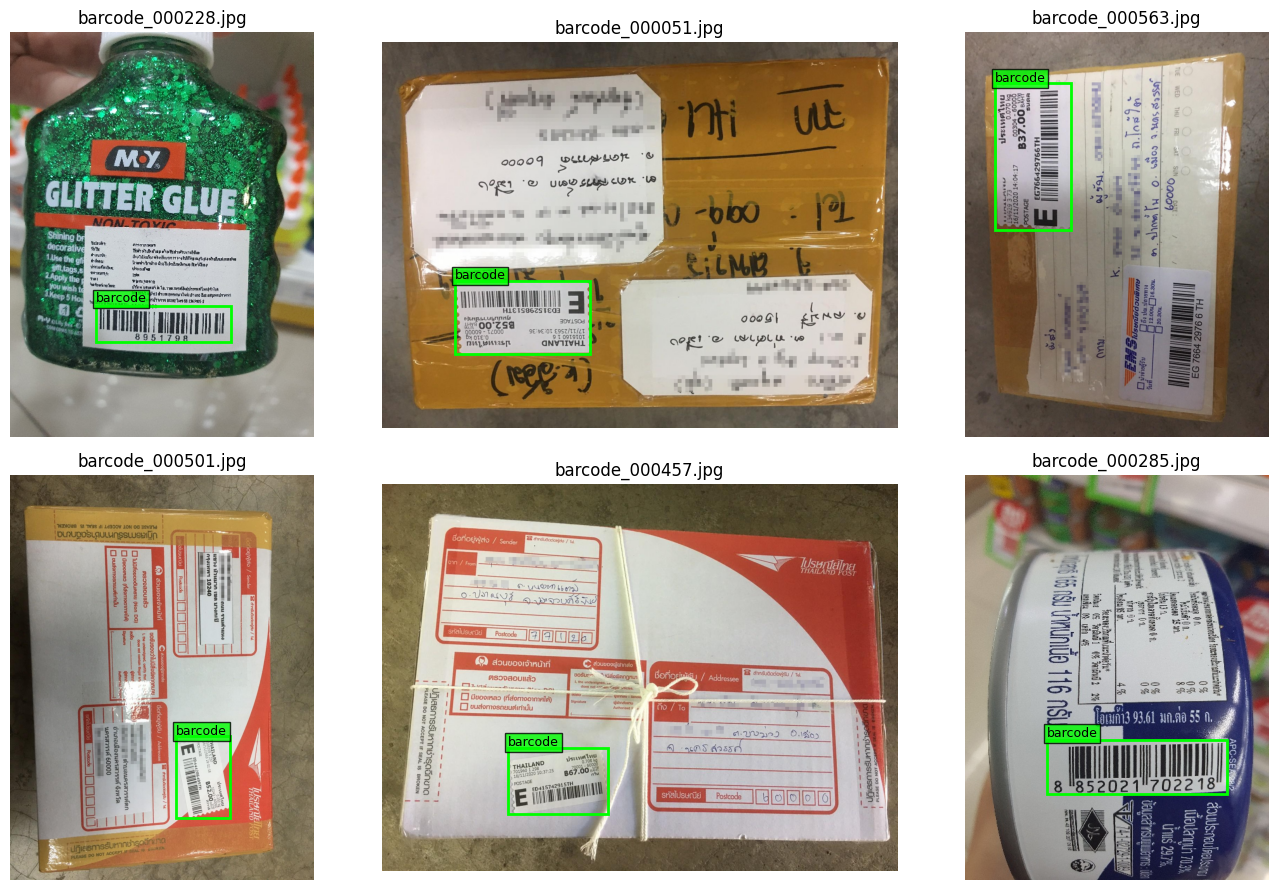

In [11]:
from __future__ import annotations


def read_yolo_boxes(label_path: Path, image_width: int, image_height: int) -> List[BBoxXYXY]:

    boxes: List[BBoxXYXY] = []

    for line in label_path.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()

        if len(parts) != 5:
            continue

        _, x_center, y_center, box_width, box_height = parts

        box = yolo_to_xyxy(
            float(x_center),
            float(y_center),
            float(box_width),
            float(box_height),
            image_width,
            image_height,
        )

        if box is not None:
            boxes.append(box)

    return boxes


def visualize_yolo_samples(sample_count: int = 6) -> None:

    image_paths = sorted((IMAGE_DIR / "train").glob("*.jpg"))

    if len(image_paths) < sample_count:
        raise ValueError(f"Not enough training images. Found {len(image_paths)}.")

    rng = random.Random(SEED)
    selected_paths = rng.sample(image_paths, sample_count)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()

    for axis, image_path in zip(axes, selected_paths):
        image = Image.open(image_path).convert("RGB")
        label_path = LABEL_DIR / "train" / f"{image_path.stem}.txt"
        boxes = read_yolo_boxes(label_path, image.width, image.height)

        axis.imshow(image)
        axis.set_title(image_path.name)
        axis.axis("off")

        for x1, y1, x2, y2 in boxes:
            rectangle = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="lime",
                facecolor="none",
            )
            axis.add_patch(rectangle)
            axis.text(
                x1,
                max(0, y1 - 5),
                "barcode",
                color="black",
                fontsize=9,
                bbox={"facecolor": "lime", "alpha": 0.8, "pad": 2},
            )

    plt.tight_layout()
    plt.show()


visualize_yolo_samples(sample_count=6)


## 3. UK Open Food Facts Local Database

This section builds a UK-focused offline product database from Open Food Facts.

Barcode detection is country-independent, but product lookup should be UK-focused for this project. Therefore, this section filters products using:

- `countries_tags` containing United Kingdom-related tags
- UK store names such as Tesco, ASDA, Sainsbury's, Morrisons, Aldi, Lidl, Waitrose, Co-op, Iceland, Ocado, and Marks & Spencer

The local database will store product information needed for:

- Product name and brand feedback
- Ingredient lookup
- Allergen warnings
- Nutrition questions
- Vegan/vegetarian and dietary-label questions
- Offline barcode lookup



In [12]:
from __future__ import annotations

import pickle
import sqlite3
from pathlib import Path
from typing import Any, Dict, List, Optional

import pandas as pd
import requests
from tqdm.auto import tqdm


OFF_CSV_URL = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"

UK_OFF_TARGET_ROWS = 200_000
UK_OFF_CHUNKSIZE = 50_000

OFF_UK_DIR = DIRS["open_food_facts"]
OFF_UK_DIR.mkdir(parents=True, exist_ok=True)

OFF_UK_SUBSET_CSV_PATH = OFF_UK_DIR / "open_food_facts_uk_subset.csv"
OFF_UK_PICKLE_PATH = OFF_UK_DIR / "open_food_facts_uk_lookup.pkl"
OFF_UK_SQLITE_PATH = OFF_UK_DIR / "open_food_facts_uk_lookup.sqlite"

OFF_COLUMNS = [
    "code",
    "product_name",
    "product_name_en",
    "brands",
    "quantity",
    "categories",
    "categories_tags",
    "ingredients_text",
    "ingredients_text_en",
    "allergens",
    "allergens_tags",
    "traces",
    "traces_tags",
    "labels",
    "labels_tags",
    "countries",
    "countries_tags",
    "stores",
    "stores_tags",
    "nutriscore_grade",
    "nova_group",
    "energy-kcal_100g",
    "fat_100g",
    "saturated-fat_100g",
    "carbohydrates_100g",
    "sugars_100g",
    "fiber_100g",
    "proteins_100g",
    "salt_100g",
    "sodium_100g",
    "url",
    "image_url",
    "last_modified_t",
    "completeness",
]

UK_COUNTRY_TAGS = [
    "en:united-kingdom",
    "en:great-britain",
    "en:england",
    "en:scotland",
    "en:wales",
    "en:northern-ireland",
]

UK_STORE_KEYWORDS = [
    "tesco",
    "sainsbury",
    "sainsburys",
    "asda",
    "morrisons",
    "aldi",
    "lidl",
    "waitrose",
    "marks",
    "spencer",
    "m&s",
    "co-op",
    "coop",
    "iceland",
    "ocado",
    "boots",
    "superdrug",
]


def check_url_available(url: str, timeout: int = 20) -> bool:

    try:
        response = requests.head(url, allow_redirects=True, timeout=timeout)
        return response.status_code < 400
    except requests.RequestException as exc:
        print(f"Warning: URL check failed: {exc}")
        return False


print(f"Open Food Facts CSV URL reachable: {check_url_available(OFF_CSV_URL)}")
print(f"UK product target rows: {UK_OFF_TARGET_ROWS:,}")
print(f"Output directory: {OFF_UK_DIR}")


Open Food Facts CSV URL reachable: False
UK product target rows: 200,000
Output directory: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/open_food_facts_uk


**Data Cleaning and Filtering**

Following the extraction process, this step defines the core functions required to clean and validate the decoded barcode data.

**Key Consideration:**
* **Preserving Leading Zeroes:** Barcodes are strictly maintained as `string` data types rather than integers. This is crucial because leading zeroes are required for accurate UPC/EAN standard matching. Dropping these zeroes would result in invalid queries when fetching product details from databases like Open Food Facts.

In [13]:
from __future__ import annotations


def normalize_barcode(value: Any) -> Optional[str]:

    if pd.isna(value):
        return None

    barcode = str(value).strip()

    if barcode.endswith(".0"):
        barcode = barcode[:-2]

    barcode = "".join(character for character in barcode if character.isdigit())

    if len(barcode) < 6:
        return None

    return barcode


def clean_text(value: Any, fallback: str = "") -> str:

    if pd.isna(value):
        return fallback

    text = str(value).strip()

    if text.lower() in {"", "nan", "none", "null"}:
        return fallback

    return text


def row_contains_uk_signal(row: pd.Series) -> bool:

    countries = clean_text(row.get("countries_tags")).lower()
    stores = clean_text(row.get("stores")).lower()
    stores_tags = clean_text(row.get("stores_tags")).lower()

    has_uk_country = any(tag in countries for tag in UK_COUNTRY_TAGS)
    has_uk_store = any(
        keyword in stores or keyword in stores_tags
        for keyword in UK_STORE_KEYWORDS
    )

    return has_uk_country or has_uk_store


def filter_open_food_facts_uk_chunk(chunk: pd.DataFrame) -> pd.DataFrame:

    chunk = chunk.copy()

    chunk["code"] = chunk["code"].apply(normalize_barcode)

    if "product_name_en" in chunk.columns:
        chunk["product_name_final"] = chunk["product_name_en"].fillna(chunk.get("product_name", ""))
    else:
        chunk["product_name_final"] = chunk.get("product_name", "")

    chunk["product_name_final"] = chunk["product_name_final"].apply(clean_text)

    chunk = chunk.dropna(subset=["code"])
    chunk = chunk[chunk["product_name_final"].str.len() > 0]

    uk_mask = chunk.apply(row_contains_uk_signal, axis=1)
    chunk = chunk[uk_mask]

    useful_columns = [
        "brands",
        "ingredients_text",
        "ingredients_text_en",
        "allergens",
        "allergens_tags",
        "labels_tags",
        "categories",
    ]
    existing_useful_columns = [column for column in useful_columns if column in chunk.columns]

    if existing_useful_columns:
        has_useful_metadata = chunk[existing_useful_columns].notna().any(axis=1)
        chunk = chunk[has_useful_metadata]

    chunk = chunk.drop_duplicates(subset=["code"], keep="first")

    return chunk


**Open Food Facts Database Acquisition and Chunk Processing**

This step handles the extraction of product information from the extensive Open Food Facts database. To strictly optimize memory usage, the raw CSV export is downloaded and processed in manageable chunks, avoiding the overhead of loading the entire dataset into RAM at once.

**Caching Mechanism:**
To expedite future runs and prevent redundant computations, the system initially checks if the filtered UK subset CSV already exists. If the file is found, the downloading and chunking processes are bypassed, and the localized subset is reused directly.

In [14]:
from __future__ import annotations


def download_open_food_facts_uk_subset(
    source_url: str,
    output_csv_path: Path,
    target_rows: int,
    chunksize: int,
) -> pd.DataFrame:

    if output_csv_path.exists():
        print(f"Loading cached UK subset: {output_csv_path}")
        return pd.read_csv(output_csv_path, dtype=str)

    selected_chunks: List[pd.DataFrame] = []
    selected_rows = 0

    try:
        csv_reader = pd.read_csv(
            source_url,
            sep="\t",
            compression="gzip",
            dtype=str,
            usecols=lambda column: column in OFF_COLUMNS,
            chunksize=chunksize,
            low_memory=False,
        )

        progress = tqdm(desc="Reading Open Food Facts chunks", unit="chunk")

        for chunk in csv_reader:
            progress.update(1)

            filtered_chunk = filter_open_food_facts_uk_chunk(chunk)

            if filtered_chunk.empty:
                continue

            selected_chunks.append(filtered_chunk)
            selected_rows += len(filtered_chunk)

            progress.set_postfix({"uk_rows": selected_rows})

            if selected_rows >= target_rows:
                break

        progress.close()

    except Exception as exc:
        raise RuntimeError(f"Failed to download or filter Open Food Facts data: {exc}") from exc

    if not selected_chunks:
        raise RuntimeError(
            "No UK products were selected."
        )

    subset = pd.concat(selected_chunks, ignore_index=True)
    subset = subset.drop_duplicates(subset=["code"], keep="first")
    subset = subset.head(target_rows)

    output_csv_path.parent.mkdir(parents=True, exist_ok=True)
    subset.to_csv(output_csv_path, index=False)

    return subset


off_uk_df = download_open_food_facts_uk_subset(
    source_url=OFF_CSV_URL,
    output_csv_path=OFF_UK_SUBSET_CSV_PATH,
    target_rows=UK_OFF_TARGET_ROWS,
    chunksize=UK_OFF_CHUNKSIZE,
)

print(f"UK Open Food Facts subset shape: {off_uk_df.shape}")
display(off_uk_df.head())


Loading cached UK subset: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/open_food_facts_uk/open_food_facts_uk_subset.csv
UK Open Food Facts subset shape: (199240, 31)


,code,url,last_modified_t,product_name,quantity,brands,categories,categories_tags,labels,labels_tags,...,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,product_name_final
0,00000031,http://world-en.openfoodfacts.org/product/0000...,1746290311,Lindt Vollmilch Schokolade,100g,Lindt,"Dried products, Dried products to be rehydrate...","en:dried-products,en:dried-products-to-be-rehy...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lindt Vollmilch Schokolade
1,00000046,http://world-en.openfoodfacts.org/product/0000...,1738109747,1up,16 oz,Streawberry shortcake,"Plant-based foods and beverages, Plant-based f...","en:plant-based-foods-and-beverages,en:plant-ba...","Organic, USDA Organic, en:non-gmo-project","en:organic,en:no-gmos,en:usda-organic,en:non-g...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1up
2,00000049,http://world-en.openfoodfacts.org/product/0000...,1733788032,Mre Lite,NaN,Redcon1,NaN,NaN,"Vegetarian, Vegan","en:vegetarian,en:vegan",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mre Lite
3,00000052,http://world-en.openfoodfacts.org/product/0000...,1738680430,Organic Erythritol Granulated,1 kg,Weight Watchers,croquettes chat,fr:croquettes-chat,"No gluten, Organic, EU Organic, Non-EU Agricul...","en:no-gluten,en:organic,en:eu-organic,en:non-e...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Organic Erythritol Granulated
4,00000064,http://world-en.openfoodfacts.org/product/0000...,1731825233,Organic hemp seeds,1kg,Sevenhills,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Organic hemp seeds


**Product Lookup Dictionary Initialization**

To enable rapid product retrieval during the inference phase, the filtered UK dataset is converted into a compact, in-memory lookup dictionary. This key-value structure ensures O(1) time complexity when matching detected barcodes to product information.

In [15]:
from __future__ import annotations


def get_best_product_name(row: pd.Series) -> str:

    name_en = clean_text(row.get("product_name_en"))
    name = clean_text(row.get("product_name"))
    final_name = clean_text(row.get("product_name_final"))

    return name_en or final_name or name or "Unnamed product"


def product_row_to_record(row: pd.Series) -> Dict[str, str]:

    ingredients = clean_text(row.get("ingredients_text_en")) or clean_text(row.get("ingredients_text"))

    return {
        "barcode": clean_text(row.get("code")),
        "name": get_best_product_name(row),
        "brand": clean_text(row.get("brands"), "Unknown brand"),
        "quantity": clean_text(row.get("quantity"), "Quantity unavailable"),
        "categories": clean_text(row.get("categories"), "Categories unavailable"),
        "categories_tags": clean_text(row.get("categories_tags")),
        "ingredients": ingredients or "Ingredients unavailable",
        "allergens": clean_text(row.get("allergens"), "Allergen information unavailable"),
        "allergens_tags": clean_text(row.get("allergens_tags")),
        "traces": clean_text(row.get("traces"), "Trace information unavailable"),
        "traces_tags": clean_text(row.get("traces_tags")),
        "labels": clean_text(row.get("labels")),
        "labels_tags": clean_text(row.get("labels_tags")),
        "countries": clean_text(row.get("countries")),
        "countries_tags": clean_text(row.get("countries_tags")),
        "stores": clean_text(row.get("stores")),
        "stores_tags": clean_text(row.get("stores_tags")),
        "nutriscore": clean_text(row.get("nutriscore_grade"), "Nutri-Score unavailable"),
        "nova_group": clean_text(row.get("nova_group"), "NOVA group unavailable"),
        "energy_kcal_100g": clean_text(row.get("energy-kcal_100g")),
        "fat_100g": clean_text(row.get("fat_100g")),
        "saturated_fat_100g": clean_text(row.get("saturated-fat_100g")),
        "carbohydrates_100g": clean_text(row.get("carbohydrates_100g")),
        "sugars_100g": clean_text(row.get("sugars_100g")),
        "fiber_100g": clean_text(row.get("fiber_100g")),
        "proteins_100g": clean_text(row.get("proteins_100g")),
        "salt_100g": clean_text(row.get("salt_100g")),
        "sodium_100g": clean_text(row.get("sodium_100g")),
        "url": clean_text(row.get("url")),
        "image_url": clean_text(row.get("image_url")),
    }


def build_product_lookup(products_df: pd.DataFrame) -> Dict[str, Dict[str, str]]:

    lookup: Dict[str, Dict[str, str]] = {}

    for _, row in tqdm(
        products_df.iterrows(),
        total=len(products_df),
        desc="Building UK product lookup",
    ):
        barcode = normalize_barcode(row.get("code"))

        if barcode is None:
            continue

        lookup[barcode] = product_row_to_record(row)

    return lookup


uk_product_lookup = build_product_lookup(off_uk_df)

with OFF_UK_PICKLE_PATH.open("wb") as file:
    pickle.dump(uk_product_lookup, file)

print(f"Lookup entries: {len(uk_product_lookup):,}")
print(f"Saved pickle lookup to: {OFF_UK_PICKLE_PATH}")

Building UK product lookup:   0%|          | 0/199240 [00:00<?, ?it/s]

Lookup entries: 199,240
Saved pickle lookup to: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/open_food_facts_uk/open_food_facts_uk_lookup.pkl


**Edge-Optimized SQLite Database Generation**

In addition to the JSON lookup dictionary, the filtered product dataset is also exported as an SQLite database.

**Why SQLite?**
SQLite is highly optimized for edge devices (e.g., Raspberry Pi, smart cameras, mobile devices). It offers critical advantages for local, real-time deployment:
* **Portability:** The entire database is contained within a single `.db` file.
* **Offline Capability:** It requires no internet connection or external API calls during inference.
* **Serverless Architecture:** It eliminates the need to install, configure, or manage a separate database server.

In [16]:
from __future__ import annotations


def save_lookup_to_sqlite(
    lookup: Dict[str, Dict[str, str]],
    sqlite_path: Path,
) -> None:

    try:
        connection = sqlite3.connect(sqlite_path)
        cursor = connection.cursor()

        cursor.execute("DROP TABLE IF EXISTS products")
        cursor.execute(
            """
            CREATE TABLE products (
                barcode TEXT PRIMARY KEY,
                name TEXT,
                brand TEXT,
                quantity TEXT,
                categories TEXT,
                categories_tags TEXT,
                ingredients TEXT,
                allergens TEXT,
                allergens_tags TEXT,
                traces TEXT,
                traces_tags TEXT,
                labels TEXT,
                labels_tags TEXT,
                countries TEXT,
                countries_tags TEXT,
                stores TEXT,
                stores_tags TEXT,
                nutriscore TEXT,
                nova_group TEXT,
                energy_kcal_100g TEXT,
                fat_100g TEXT,
                saturated_fat_100g TEXT,
                carbohydrates_100g TEXT,
                sugars_100g TEXT,
                fiber_100g TEXT,
                proteins_100g TEXT,
                salt_100g TEXT,
                sodium_100g TEXT,
                url TEXT,
                image_url TEXT
            )
            """
        )

        records = []

        for barcode, product in lookup.items():
            records.append(
                (
                    barcode,
                    product.get("name", ""),
                    product.get("brand", ""),
                    product.get("quantity", ""),
                    product.get("categories", ""),
                    product.get("categories_tags", ""),
                    product.get("ingredients", ""),
                    product.get("allergens", ""),
                    product.get("allergens_tags", ""),
                    product.get("traces", ""),
                    product.get("traces_tags", ""),
                    product.get("labels", ""),
                    product.get("labels_tags", ""),
                    product.get("countries", ""),
                    product.get("countries_tags", ""),
                    product.get("stores", ""),
                    product.get("stores_tags", ""),
                    product.get("nutriscore", ""),
                    product.get("nova_group", ""),
                    product.get("energy_kcal_100g", ""),
                    product.get("fat_100g", ""),
                    product.get("saturated_fat_100g", ""),
                    product.get("carbohydrates_100g", ""),
                    product.get("sugars_100g", ""),
                    product.get("fiber_100g", ""),
                    product.get("proteins_100g", ""),
                    product.get("salt_100g", ""),
                    product.get("sodium_100g", ""),
                    product.get("url", ""),
                    product.get("image_url", ""),
                )
            )

        for start in tqdm(range(0, len(records), 1000), desc="Writing SQLite batches"):
            cursor.executemany(
                 """
                INSERT OR REPLACE INTO products VALUES (
                    ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?,
                    ?, ?, ?, ?, ?, ?, ?, ?, ?, ?
                )
                """,
                records[start:start + 1000],
            )

        connection.commit()
        connection.close()

    except Exception as exc:
        raise RuntimeError(f"Failed to save SQLite lookup database: {exc}") from exc


save_lookup_to_sqlite(uk_product_lookup, OFF_UK_SQLITE_PATH)

print(f"Saved SQLite lookup to: {OFF_UK_SQLITE_PATH}")


Writing SQLite batches:   0%|          | 0/200 [00:00<?, ?it/s]

Saved SQLite lookup to: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/open_food_facts_uk/open_food_facts_uk_lookup.sqlite


**Edge-Optimized SQLite Database Generation**

To ensure rapid, offline product retrieval on edge devices, the filtered product lookup dictionary is exported into a comprehensive SQLite database.

**Key Implementation Details:**
* **Rich Data Schema:** The database structure is expanded to capture extensive product metadata, including detailed nutrition facts, allergens, trace elements, and image URLs.
* **Optimized I/O Operations:** Records are committed to the database in batches of 1000 using `tqdm`, which optimizes memory usage and provides real-time progress tracking.
* **Offline Portability:** The resulting `.db` file requires no external server infrastructure, making it fully self-contained for edge deployment.

In [17]:
from __future__ import annotations


PRODUCT_UNAVAILABLE_MESSAGE = "Product information unavailable"


def barcode_variants(barcode: str) -> List[str]:

    code = "".join(character for character in str(barcode) if character.isdigit())

    if not code:
        return []

    variants = {code}

    if len(code) == 12:
        variants.add("0" + code)

    if len(code) == 13 and code.startswith("0"):
        variants.add(code[1:])

    if len(code) < 13:
        variants.add(code.zfill(13))

    if len(code) < 14:
        variants.add(code.zfill(14))

    return list(variants)


def lookup_product(barcode: str) -> Dict[str, str]:

    for variant in barcode_variants(barcode):
        product = uk_product_lookup.get(variant)

        if product is not None:
            result = dict(product)
            result["found"] = "true"
            result["matched_barcode"] = variant
            return result

    return {
        "barcode": str(barcode),
        "name": PRODUCT_UNAVAILABLE_MESSAGE,
        "brand": "",
        "ingredients": "",
        "allergens": "",
        "allergens_tags": "",
        "labels": "",
        "labels_tags": "",
        "found": "false",
        "matched_barcode": "",
    }


sample_barcodes = list(uk_product_lookup.keys())[:5] + ["0000000000000"]

for barcode in sample_barcodes:
    product = lookup_product(barcode)
    print("-" * 80)
    print(f"Input barcode: {barcode}")
    print(f"Found: {product.get('found')}")
    print(f"Matched barcode: {product.get('matched_barcode')}")
    print(f"Name: {product.get('name')}")
    print(f"Brand: {product.get('brand')}")
    print(f"Ingredients: {product.get('ingredients', '')[:180]}")

--------------------------------------------------------------------------------
Input barcode: 00000031
Found: true
Matched barcode: 00000031
Name: Lindt Vollmilch Schokolade
Brand: Lindt
Ingredients: salt, potato starch, palm oil, yeast extract, sugar, chicken fat, flavouring, chicken powder, onion powder, turmeric powder, celery seed, parsley, rice flour, black pepper, lemon j
--------------------------------------------------------------------------------
Input barcode: 00000046
Found: true
Matched barcode: 00000046
Name: 1up
Brand: Streawberry shortcake
Ingredients: Ingredients unavailable
--------------------------------------------------------------------------------
Input barcode: 00000049
Found: true
Matched barcode: 00000049
Name: Mre Lite
Brand: Redcon1
Ingredients: Whole Food Protein Blend (Beef Protein Isolate, Pea Protein, Brown Rice Protein, Chicken Protein, Egg Albumin, Salmon Protein), Milk Powder (for texture), Medium Chain Triglyceride
-------------------------------

## 4. YOLOv8-Nano Barcode Detector Training

This section trains the baseline barcode detector using YOLOv8-Nano.

YOLOv8-Nano is suitable for edge deployment because it is small, fast, and has low computational cost compared with larger YOLO variants.

Training configuration:

- Starting checkpoint: `yolov8n.pt`
- Epochs: 50
- Image size: 640
- Batch size: 16
- Dataset: InventBar + ParcelBar converted to YOLO format
- Metrics: precision, recall, mAP@0.5, mAP@0.5:0.95

The best trained model is saved as:

`baseline_yolov8n_barcode.pt`


In [18]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict

import pandas as pd
from ultralytics import YOLO


BASELINE_MODEL_NAME = "yolov8n.pt"

TRAIN_EPOCHS = 50
TRAIN_IMAGE_SIZE = 640
TRAIN_BATCH_SIZE = 16

BASELINE_RUN_NAME = "baseline_yolov8n_uk_barcode"
BASELINE_WEIGHTS_PATH = DIRS["models"] / "baseline_yolov8n_barcode.pt"
BASELINE_RESULTS_CSV_PATH = DIRS["benchmarks"] / "baseline_training_results.csv"

print(f"YOLO data file: {DATA_YAML_PATH}")
print(f"Baseline weights output: {BASELINE_WEIGHTS_PATH}")
print(f"Training device: {DEVICE}")


YOLO data file: /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/barcode_detection/yolo_inventbar_parcelbar/data.yaml
Baseline weights output: /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.pt
Training device: cuda


**Dataset Integrity Validation**

Before initiating the computationally intensive training process, it is critical to validate the integrity of the finalized YOLO dataset. This sanity check ensures that the expected directory structures exist and that each data partition (`train`, `val`, `test`) is properly populated with both images and their corresponding label files.

In [19]:
from __future__ import annotations


def validate_yolo_dataset(data_yaml_path: Path) -> None:

    required_paths = [
        data_yaml_path,
        IMAGE_DIR / "train",
        IMAGE_DIR / "val",
        IMAGE_DIR / "test",
        LABEL_DIR / "train",
        LABEL_DIR / "val",
        LABEL_DIR / "test",
    ]

    missing_paths = [path for path in required_paths if not path.exists()]

    if missing_paths:
        missing_text = "\n".join(str(path) for path in missing_paths)
        raise FileNotFoundError(f"Missing YOLO dataset paths:\n{missing_text}")

    split_counts = {
        "train": len(list((IMAGE_DIR / "train").glob("*.jpg"))),
        "val": len(list((IMAGE_DIR / "val").glob("*.jpg"))),
        "test": len(list((IMAGE_DIR / "test").glob("*.jpg"))),
    }

    if any(count == 0 for count in split_counts.values()):
        raise ValueError(f"One or more YOLO splits are empty: {split_counts}")

    print("YOLO dataset split counts:")
    for split_name, count in split_counts.items():
        print(f"{split_name}: {count}")


validate_yolo_dataset(DATA_YAML_PATH)


YOLO dataset split counts:
train: 1096
val: 137
test: 138


**Model Training (YOLOv8-Nano)**

This phase initiates the core training of the YOLOv8-Nano model utilizing the prepared and validated barcode dataset. The Nano architecture (`yolov8n.pt`) is deliberately selected for its minimal parameter count and high-speed inference, making it highly optimal for subsequent edge deployment.

**Full Training:** The default loop is configured for `50` epochs to allow the model to adequately converge and learn robust feature representations.


In [20]:
from __future__ import annotations


def train_baseline_yolov8n() -> Any:

    try:
        model = YOLO(BASELINE_MODEL_NAME)

        results = model.train(
            data=str(DATA_YAML_PATH),
            epochs=TRAIN_EPOCHS,
            imgsz=TRAIN_IMAGE_SIZE,
            batch=TRAIN_BATCH_SIZE,
            device=0 if DEVICE == "cuda" else "cpu",
            project=str(DIRS["runs"]),
            name=BASELINE_RUN_NAME,
            seed=SEED,
            deterministic=True,
            pretrained=True,
            patience=10,
            workers=2,
            exist_ok=True,
        )

        return results

    except Exception as exc:
        raise RuntimeError(f"YOLOv8-Nano baseline training failed: {exc}") from exc


baseline_train_results = train_baseline_yolov8n()

print("Baseline YOLOv8-Nano training finished.")


Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/uk_edge_ai_barcode_reader/data/barcode_detection/yolo_inventbar_parcelbar/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_yolov8n_uk_barcode, 

**Exporting the Optimal Model Checkpoint**

Upon the completion of the training phase, YOLOv8 automatically saves the highest-performing model weights deeply within a dynamic run directory. To streamline subsequent stages—such as object detection, model optimization (quantization), performance benchmarking, and the Streamlit camera interface—we extract this best checkpoint and save it to a stable, easily accessible path.

In [21]:
from __future__ import annotations


def find_best_weight_path(run_dir: Path, run_name: str) -> Path:
    expected_path = run_dir / run_name / "weights" / "best.pt"

    if expected_path.exists():
        return expected_path

    candidate_paths = sorted(run_dir.glob(f"{run_name}*/weights/best.pt"))

    if not candidate_paths:
        raise FileNotFoundError(f"No best.pt found under {run_dir} for run {run_name}")

    return candidate_paths[-1]


def save_baseline_weights(best_weight_path: Path, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(best_weight_path, output_path)


best_weight_path = find_best_weight_path(DIRS["runs"], BASELINE_RUN_NAME)
save_baseline_weights(best_weight_path, BASELINE_WEIGHTS_PATH)

print(f"Best checkpoint: {best_weight_path}")
print(f"Saved baseline model: {BASELINE_WEIGHTS_PATH}")


Best checkpoint: /content/drive/MyDrive/uk_edge_ai_barcode_reader/runs/baseline_yolov8n_uk_barcode/weights/best.pt
Saved baseline model: /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.pt


**Model Evaluation and Benchmarking**

After successfully training the baseline YOLOv8 model, it is crucial to objectively measure its performance. The following cell defines an evaluation function that extracts core object detection metrics (Precision, Recall, mAP50, and mAP50-95) directly from the model's validation outputs.

**Evaluation Strategy:**
* **Validation Split (`val`):** Evaluates performance on the dataset split used for monitoring during the training phase.
* **Test Split (`test`):** Benchmarks the model on completely unseen data to provide the most accurate representation of its real-world, edge-deployment accuracy.

In [22]:
from __future__ import annotations


def evaluate_yolo_model(
    model_path: Path,
    split_name: str = "test",
    image_size: int = 640,
) -> Dict[str, float]:
    try:
        model = YOLO(str(model_path))

        metrics = model.val(
            data=str(DATA_YAML_PATH),
            split=split_name,
            imgsz=image_size,
            batch=TRAIN_BATCH_SIZE,
            device=0 if DEVICE == "cuda" else "cpu",
            project=str(DIRS["runs"]),
            name=f"eval_{model_path.stem}_{split_name}",
            exist_ok=True,
            verbose=False,
        )

        return {
            "precision": float(metrics.box.mp),
            "recall": float(metrics.box.mr),
            "map50": float(metrics.box.map50),
            "map50_95": float(metrics.box.map),
        }

    except Exception as exc:
        raise RuntimeError(f"Evaluation failed for {model_path} on {split_name}: {exc}") from exc


baseline_val_metrics = evaluate_yolo_model(BASELINE_WEIGHTS_PATH, split_name="val")
baseline_test_metrics = evaluate_yolo_model(BASELINE_WEIGHTS_PATH, split_name="test")

print("Validation metrics:")
for key, value in baseline_val_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nTest metrics:")
for key, value in baseline_test_metrics.items():
    print(f"{key}: {value:.4f}")


Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 8.4±17.8 ms, read: 88.1±68.8 MB/s, size: 294.7 KB)
val: Scanning /content/drive/MyDrive/uk_edge_ai_barcode_reader/data/barcode_detection/yolo_inventbar_parcelbar/labels/val.cache... 137 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 137/137 44.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.8it/s 4.9s
                   all        137        155      0.981       0.98      0.983      0.883
Speed: 2.9ms preprocess, 5.6ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/drive/MyDrive/uk_edge_ai_barcode_reader/runs/eval_baseline_yolov8n_barcode_val
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gr

**Training Log Visualization**

To understand the learning dynamics of our model, we examine the training logs generated by Ultralytics. Visualizing the learning curves (loss metrics, precision, recall, and mAP over epochs) is essential to diagnose potential issues like overfitting or underfitting.

**What we are checking:**
* **Loss Curves:** Both box loss and class loss should steadily decrease.
* **mAP Curves:** Mean Average Precision should increase and eventually plateau, indicating that the model has converged.

In [23]:
from __future__ import annotations


def load_training_results(run_dir: Path, run_name: str) -> pd.DataFrame:

    expected_csv = run_dir / run_name / "results.csv"

    if expected_csv.exists():
        return pd.read_csv(expected_csv)

    candidate_csvs = sorted(run_dir.glob(f"{run_name}*/results.csv"))

    if not candidate_csvs:
        raise FileNotFoundError(f"No results.csv found for run {run_name}")

    return pd.read_csv(candidate_csvs[-1])


training_results_df = load_training_results(DIRS["runs"], BASELINE_RUN_NAME)
training_results_df.to_csv(BASELINE_RESULTS_CSV_PATH, index=False)

print(f"Saved training results to: {BASELINE_RESULTS_CSV_PATH}")
display(training_results_df.tail())


Saved training results to: /content/drive/MyDrive/uk_edge_ai_barcode_reader/benchmarks/baseline_training_results.csv


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,1406.74,0.41560,0.26272,0.85235,0.97418,0.97365,0.98070,0.88193,0.48876,0.27682,0.91321,0.000218,0.000218,0.000218
46,47,1435.52,0.40847,0.25760,0.84908,0.97842,0.98065,0.98173,0.87871,0.48297,0.26941,0.91126,0.000178,0.000178,0.000178
47,48,1465.45,0.39459,0.24997,0.84039,0.98062,0.97924,0.98166,0.88337,0.47601,0.26762,0.90485,0.000139,0.000139,0.000139
48,49,1495.42,0.39532,0.24786,0.84191,0.98062,0.97947,0.98287,0.88753,0.47478,0.25807,0.90685,0.000099,0.000099,0.000099
49,50,1525.37,0.38626,0.23976,0.84312,0.98063,0.97976,0.98341,0.88431,0.47080,0.25648,0.90437,0.000060,0.000060,0.000060


**Custom Visualization of Training Metrics**

While Ultralytics generates default summary images, parsing the raw `results.csv` allows for the creation of custom, publication-ready visualizations. In this step, we utilize `matplotlib` to specifically extract and plot the most critical indicators of model performance.

**Plotted Metrics:**
* **Box Loss (Train vs. Validation):** Monitors how well the model learns to draw bounding boxes and helps identify signs of overfitting (e.g., if train loss decreases while validation loss increases).
* **Mean Average Precision (mAP):** Tracks the overall detection accuracy across epochs, specifically focusing on mAP@50 and mAP@50-95.

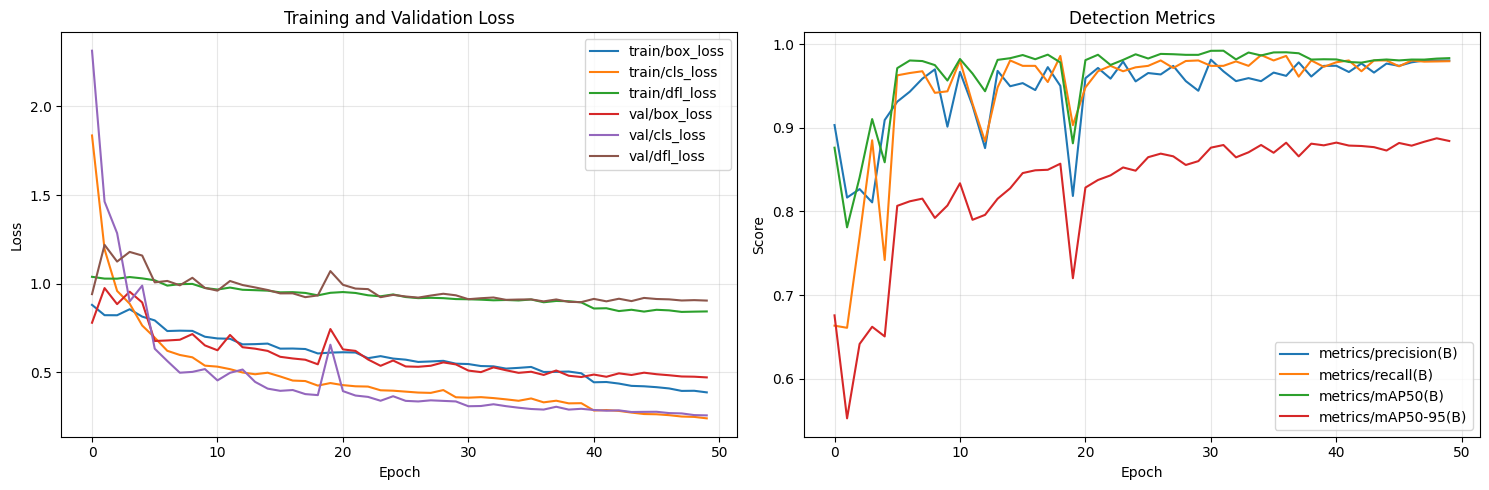

In [24]:
from __future__ import annotations


def plot_training_curves(results_df: pd.DataFrame) -> None:

    metric_candidates = [
        "train/box_loss",
        "train/cls_loss",
        "train/dfl_loss",
        "val/box_loss",
        "val/cls_loss",
        "val/dfl_loss",
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
    ]

    available_metrics = [column for column in metric_candidates if column in results_df.columns]

    if not available_metrics:
        print("No standard YOLO metric columns were found.")
        return

    loss_columns = [column for column in available_metrics if "loss" in column]
    score_columns = [column for column in available_metrics if "metrics" in column]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for column in loss_columns:
        axes[0].plot(results_df[column], label=column)

    axes[0].set_title("Training and Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    for column in score_columns:
        axes[1].plot(results_df[column], label=column)

    axes[1].set_title("Detection Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(training_results_df)


## 5. Model Optimization

This section creates optimized versions of the trained YOLOv8-Nano barcode detector.

The project compares four model variants:

1. Baseline PyTorch model
2. FP16 ONNX model
3. INT8 ONNX model
4. 30% pruned PyTorch model

Optimization is important because the target deployment environment is an edge device, where latency, memory usage, and model size matter.


In [25]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, Iterator, List, Optional, Tuple

import numpy as np
import onnx
import onnxruntime as ort
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from onnxruntime.quantization import (
    CalibrationDataReader,
    CalibrationMethod,
    QuantFormat,
    QuantType,
    quantize_static,
)
from tqdm.auto import tqdm
from ultralytics import YOLO


OPTIMIZED_MODEL_DIR = DIRS["optimized_models"]
OPTIMIZED_MODEL_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_ONNX_FP32_PATH = OPTIMIZED_MODEL_DIR / "baseline_yolov8n_barcode_fp32.onnx"
FP16_ONNX_PATH = OPTIMIZED_MODEL_DIR / "yolov8n_barcode_fp16.onnx"
INT8_ONNX_PATH = OPTIMIZED_MODEL_DIR / "yolov8n_barcode_int8.onnx"
PRUNED_WEIGHTS_PATH = OPTIMIZED_MODEL_DIR / "yolov8n_barcode_pruned_30.pt"

PRUNED_RUN_NAME = "pruned_yolov8n_barcode_30_finetune"

PRUNING_SPARSITY = 0.30
PRUNING_FINETUNE_EPOCHS = 10
CALIBRATION_IMAGE_COUNT = 100

print(f"Baseline model: {BASELINE_WEIGHTS_PATH}")
print(f"Optimized model directory: {OPTIMIZED_MODEL_DIR}")


Baseline model: /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.pt
Optimized model directory: /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/optimized


**Model Optimization: FP16 Quantization**

To prepare our trained model for real-world edge deployment, we apply FP16 (Half-Precision) quantization.

**Why FP16?**
Exporting the model to half-precision significantly reduces the overall model file size and memory footprint. More importantly, it dramatically improves inference speed on GPU-enabled edge architectures without a noticeable drop in detection accuracy.

In [26]:
from __future__ import annotations


def export_yolo_to_onnx(
    model_path: Path,
    output_path: Path,
    image_size: int = 640,
    half: bool = False,
) -> Path:

    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")

    try:
        model = YOLO(str(model_path))

        export_device = 0 if DEVICE == "cuda" else "cpu"

        if half and DEVICE != "cuda":
            raise RuntimeError("FP16 ONNX export requires a GPU runtime. Enable GPU in Colab.")

        exported_path = model.export(
            format="onnx",
            imgsz=image_size,
            half=half,
            dynamic=False,
            simplify=False,
            opset=12,
            device=export_device,
        )

        exported_path = Path(exported_path)

        if not exported_path.exists():
            raise FileNotFoundError(f"ONNX export did not create file: {exported_path}")

        output_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(exported_path, output_path)

        return output_path

    except Exception as exc:
        precision = "FP16" if half else "FP32"
        raise RuntimeError(f"{precision} ONNX export failed: {exc}") from exc


BASELINE_ONNX_FP32_PATH = export_yolo_to_onnx(
    model_path=BASELINE_WEIGHTS_PATH,
    output_path=BASELINE_ONNX_FP32_PATH,
    image_size=TRAIN_IMAGE_SIZE,
    half=False,
)

FP16_ONNX_PATH = export_yolo_to_onnx(
    model_path=BASELINE_WEIGHTS_PATH,
    output_path=FP16_ONNX_PATH,
    image_size=TRAIN_IMAGE_SIZE,
    half=True,
)

print(f"Saved FP32 ONNX model: {BASELINE_ONNX_FP32_PATH}")
print(f"Saved FP16 ONNX model: {FP16_ONNX_PATH}")


Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)

ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: export success ✅ 1.7s, saved as '/content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.onnx' (11.7 MB)

Export complete (1.9s)
Results saved to /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.onnx imgsz=640 
Validate:        yolo val task=detect model=

**ONNX Model Validation**

Before proceeding to performance benchmarking or edge deployment, it is a critical best practice to mathematically validate the exported ONNX models. The conversion process can occasionally introduce graph errors or unsupported operations.

**Validation Objectives:**
* **Graph Integrity:** Ensures the ONNX file is structurally sound and strictly follows the ONNX specification.
* **I/O Verification:** Confirms the model's input and output node shapes match the expected parameters (e.g., $1 \times 3 \times 640 \times 640$ image tensors) to prevent runtime crashes on the target device.

In [27]:
from __future__ import annotations


def validate_onnx_model(model_path: Path) -> Dict[str, Any]:

    if not model_path.exists():
        raise FileNotFoundError(f"ONNX file not found: {model_path}")

    try:
        onnx_model = onnx.load(str(model_path))
        onnx.checker.check_model(onnx_model)

        providers = (
            ["CUDAExecutionProvider", "CPUExecutionProvider"]
            if "CUDAExecutionProvider" in ort.get_available_providers()
            else ["CPUExecutionProvider"]
        )

        session = ort.InferenceSession(str(model_path), providers=providers)

        return {
            "path": str(model_path),
            "inputs": [
                {
                    "name": input_meta.name,
                    "shape": input_meta.shape,
                    "type": input_meta.type,
                }
                for input_meta in session.get_inputs()
            ],
            "outputs": [
                {
                    "name": output_meta.name,
                    "shape": output_meta.shape,
                    "type": output_meta.type,
                }
                for output_meta in session.get_outputs()
            ],
        }

    except Exception as exc:
        raise RuntimeError(f"ONNX validation failed for {model_path}: {exc}") from exc


fp32_info = validate_onnx_model(BASELINE_ONNX_FP32_PATH)
fp16_info = validate_onnx_model(FP16_ONNX_PATH)

print("FP32 ONNX inputs:")
print(fp32_info["inputs"])

print("\nFP16 ONNX inputs:")
print(fp16_info["inputs"])


FP32 ONNX inputs:
[{'name': 'images', 'shape': [1, 3, 640, 640], 'type': 'tensor(float)'}]

FP16 ONNX inputs:
[{'name': 'images', 'shape': [1, 3, 640, 640], 'type': 'tensor(float16)'}]


**Model Optimization: INT8 Static Quantization**

For maximum deployment efficiency—particularly on edge CPUs, mobile devices, or specialized NPU accelerators—we apply INT8 static quantization. This aggressive optimization compresses the model's weights and activations into 8-bit integers, significantly minimizing memory consumption and maximizing inference speed.

**Calibration Strategy:**
To preserve detection accuracy after such heavy compression, static quantization requires a calibration phase. Using the ONNX Runtime, we feed 100 sample images from our training split into the model. This allows the system to accurately observe and estimate the real-world activation ranges before locking the final 8-bit deployment model.

In [28]:
from __future__ import annotations


def letterbox_image(
    image_rgb: np.ndarray,
    target_size: int = 640,
    color: Tuple[int, int, int] = (114, 114, 114),
) -> np.ndarray:

    height, width = image_rgb.shape[:2]
    scale = min(target_size / height, target_size / width)

    new_width = int(round(width * scale))
    new_height = int(round(height * scale))

    resized = cv2.resize(image_rgb, (new_width, new_height), interpolation=cv2.INTER_LINEAR)

    canvas = np.full((target_size, target_size, 3), color, dtype=np.uint8)

    top = (target_size - new_height) // 2
    left = (target_size - new_width) // 2

    canvas[top:top + new_height, left:left + new_width] = resized

    return canvas


def preprocess_image_for_onnx(image_path: Path, image_size: int = 640) -> np.ndarray:

    try:
        image_bgr = cv2.imread(str(image_path))

        if image_bgr is None:
            raise ValueError(f"OpenCV could not read image: {image_path}")

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        image_rgb = letterbox_image(image_rgb, target_size=image_size)
        image_rgb = image_rgb.astype(np.float32) / 255.0

        tensor = np.transpose(image_rgb, (2, 0, 1))[None, :, :, :]

        return tensor.astype(np.float32)

    except Exception as exc:
        raise RuntimeError(f"Failed to preprocess calibration image {image_path}: {exc}") from exc


def get_calibration_image_paths(count: int = 100) -> List[Path]:

    image_paths = sorted((IMAGE_DIR / "train").glob("*.jpg"))

    if len(image_paths) < count:
        raise ValueError(f"Need {count} calibration images, but found {len(image_paths)}.")

    rng = random.Random(SEED)
    return rng.sample(image_paths, count)


class YOLOCalibrationDataReader(CalibrationDataReader):

    def __init__(
        self,
        image_paths: List[Path],
        input_name: str,
        image_size: int = 640,
    ) -> None:

        self.image_paths = image_paths
        self.input_name = input_name
        self.image_size = image_size
        self._iterator: Optional[Iterator[Dict[str, np.ndarray]]] = None

    def _data_iterator(self) -> Iterator[Dict[str, np.ndarray]]:
        for image_path in tqdm(self.image_paths, desc="Preparing INT8 calibration images"):
            tensor = preprocess_image_for_onnx(image_path, image_size=self.image_size)
            yield {self.input_name: tensor}

    def get_next(self) -> Optional[Dict[str, np.ndarray]]:
        if self._iterator is None:
            self._iterator = self._data_iterator()

        return next(self._iterator, None)

    def rewind(self) -> None:
        self._iterator = None


**Model Optimization: FP32 to INT8 Static Quantization**

To achieve maximum inference speed on edge CPUs and NPUs, we apply INT8 static quantization. This process aggressively reduces the model's weights and activations to 8-bit integer values.

**Calibration Strategy & FP32 Requirement:**
Static INT8 quantization requires a calibration phase to observe and estimate real-world activation ranges before locking the weights. To ensure the highest calibration accuracy, the **FP32 (full-precision)** ONNX model is explicitly used as the source rather than the FP16 model. Using 100 sample images from the training split, the ONNX Runtime evaluates the FP32 model to accurately map the floating-point values into optimal 8-bit integers.

In [29]:
from __future__ import annotations


def quantize_onnx_to_int8(
    fp32_onnx_path: Path,
    int8_onnx_path: Path,
    calibration_count: int = 100,
) -> Path:

    if not fp32_onnx_path.exists():
        raise FileNotFoundError(f"FP32 ONNX model not found: {fp32_onnx_path}")

    try:
        session = ort.InferenceSession(str(fp32_onnx_path), providers=["CPUExecutionProvider"])
        input_name = session.get_inputs()[0].name

        calibration_paths = get_calibration_image_paths(calibration_count)

        calibration_reader = YOLOCalibrationDataReader(
            image_paths=calibration_paths,
            input_name=input_name,
            image_size=TRAIN_IMAGE_SIZE,
        )


        quantize_static(
            model_input=str(fp32_onnx_path),
            model_output=str(int8_onnx_path),
            calibration_data_reader=calibration_reader,
            quant_format=QuantFormat.QDQ,
            activation_type=QuantType.QUInt8,
            weight_type=QuantType.QInt8,
            calibrate_method=CalibrationMethod.MinMax,
            per_channel=True,
            reduce_range=False,
        )

        if not int8_onnx_path.exists():
            raise FileNotFoundError(f"INT8 model was not created: {int8_onnx_path}")

        return int8_onnx_path

    except Exception as exc:
        raise RuntimeError(f"INT8 quantization failed: {exc}") from exc


INT8_ONNX_PATH = quantize_onnx_to_int8(
    fp32_onnx_path=BASELINE_ONNX_FP32_PATH,
    int8_onnx_path=INT8_ONNX_PATH,
    calibration_count=CALIBRATION_IMAGE_COUNT,
)

try:
    int8_info = validate_onnx_model(INT8_ONNX_PATH)
    print(f"Saved INT8 ONNX model: {INT8_ONNX_PATH}")
    print("INT8 ONNX inputs:")
    print(int8_info["inputs"])
except Exception as e:
    print(f"Validation skipped but model saved: {INT8_ONNX_PATH}")
    print(f"Reason: {e}")

Preparing INT8 calibration images:   0%|          | 0/100 [00:00<?, ?it/s]

Validation skipped but model saved: /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/optimized/yolov8n_barcode_int8.onnx
Reason: ONNX validation failed for /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/optimized/yolov8n_barcode_int8.onnx: Unrecognized attribute: axis for operator DequantizeLinear

==> Context: Bad node spec for node. Name: model.0.conv.bias_DequantizeLinear OpType: DequantizeLinear


**Model Optimization: Unstructured Magnitude Pruning**

To further explore edge optimization trade-offs, we apply Model Pruning. This technique systematically removes low-magnitude weights (parameters close to zero) from the neural network, effectively creating a sparser model.

**Pruning Strategy & Considerations:**
* **30% Global Unstructured Pruning:** We target the Convolutional layers (`Conv2d`), pruning 30% of their lowest-magnitude weights across the network.
* **Accuracy Recovery (Fine-Tuning):** Pruning inherently degrades initial accuracy. To recover this, we perform a rapid fine-tuning phase for 10 epochs.
* **Hardware Note:** Unstructured pruning may not strictly reduce physical file size or dramatically improve runtime speed unless the target deployment backend (like specific NPU drivers) is explicitly designed to exploit sparse matrix operations. However, it remains a highly valuable technique for evaluating extreme optimization limits.

In [30]:
from __future__ import annotations


def collect_prunable_modules(torch_model: nn.Module) -> List[Tuple[nn.Module, str]]:
    prunable_modules: List[Tuple[nn.Module, str]] = []

    for module in torch_model.modules():
        if isinstance(module, nn.Conv2d):
            prunable_modules.append((module, "weight"))

    if not prunable_modules:
        raise ValueError("No Conv2d modules were found for pruning.")

    return prunable_modules


def calculate_model_sparsity(torch_model: nn.Module) -> float:
    zero_count = 0
    total_count = 0

    for parameter in torch_model.parameters():
        data = parameter.detach()
        zero_count += int(torch.sum(data == 0).item())
        total_count += data.numel()

    if total_count == 0:
        return 0.0

    return zero_count / total_count


def apply_global_unstructured_pruning(
    yolo_model: YOLO,
    sparsity: float = 0.30,
) -> YOLO:
    try:
        torch_model = yolo_model.model
        prunable_modules = collect_prunable_modules(torch_model)

        prune.global_unstructured(
            prunable_modules,
            pruning_method=prune.L1Unstructured,
            amount=sparsity,
        )

        for module, parameter_name in tqdm(prunable_modules, desc="Making pruning permanent"):
            prune.remove(module, parameter_name)

        return yolo_model

    except Exception as exc:
        raise RuntimeError(f"Global pruning failed: {exc}") from exc


**Model Optimization: Pruning and Fine-Tuning**

In this advanced optimization step, we apply **30% global unstructured magnitude pruning** to the model's convolutional layers. Pruning systematically removes low-magnitude weights, effectively creating a sparser neural network.


In [31]:
from __future__ import annotations


def prune_and_finetune_yolo_model(
    baseline_model_path: Path,
    pruned_output_path: Path,
    sparsity: float,
    finetune_epochs: int,
) -> Path:

    if not baseline_model_path.exists():
        raise FileNotFoundError(f"Baseline model not found: {baseline_model_path}")

    try:
        yolo_model = YOLO(str(baseline_model_path))
        yolo_model = apply_global_unstructured_pruning(yolo_model, sparsity=sparsity)

        sparsity_after_pruning = calculate_model_sparsity(yolo_model.model)
        print(f"Observed sparsity after pruning: {sparsity_after_pruning:.2%}")

        temporary_pruned_path = OPTIMIZED_MODEL_DIR / "temporary_pruned_before_finetune.pt"
        yolo_model.save(str(temporary_pruned_path))

        pruned_model = YOLO(str(temporary_pruned_path))

        pruned_model.train(
            data=str(DATA_YAML_PATH),
            epochs=finetune_epochs,
            imgsz=TRAIN_IMAGE_SIZE,
            batch=TRAIN_BATCH_SIZE,
            device=0 if DEVICE == "cuda" else "cpu",
            project=str(DIRS["runs"]),
            name=PRUNED_RUN_NAME,
            seed=SEED,
            deterministic=True,
            patience=5,
            workers=2,
            exist_ok=True,
        )

        best_pruned_path = find_best_weight_path(DIRS["runs"], PRUNED_RUN_NAME)

        pruned_output_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(best_pruned_path, pruned_output_path)

        return pruned_output_path

    except Exception as exc:
        raise RuntimeError(f"Pruning and fine-tuning failed: {exc}") from exc


PRUNED_WEIGHTS_PATH = prune_and_finetune_yolo_model(
    baseline_model_path=BASELINE_WEIGHTS_PATH,
    pruned_output_path=PRUNED_WEIGHTS_PATH,
    sparsity=PRUNING_SPARSITY,
    finetune_epochs=PRUNING_FINETUNE_EPOCHS,
)

print(f"Saved pruned model: {PRUNED_WEIGHTS_PATH}")


Making pruning permanent:   0%|          | 0/64 [00:00<?, ?it/s]

Observed sparsity after pruning: 29.89%
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/uk_edge_ai_barcode_reader/data/barcode_detection/yolo_inventbar_parcelbar/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/uk_edge_ai_barcode_reader/mo

**Summary of Optimized Model Variants**

Having applied multiple optimization techniques (FP16/INT8 Quantization and Pruning), we now summarize the generated model variants and inspect their physical file sizes on disk.


In [32]:
from __future__ import annotations


def get_file_size_mb(file_path: Path) -> float:
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    return file_path.stat().st_size / (1024 * 1024)


def summarize_model_variants() -> pd.DataFrame:
    records = [
        {
            "variant": "Baseline",
            "format": "PyTorch",
            "path": str(BASELINE_WEIGHTS_PATH),
            "size_mb": get_file_size_mb(BASELINE_WEIGHTS_PATH),
        },
        {
            "variant": "FP32 ONNX",
            "format": "ONNX",
            "path": str(BASELINE_ONNX_FP32_PATH),
            "size_mb": get_file_size_mb(BASELINE_ONNX_FP32_PATH),
        },
        {
            "variant": "FP16",
            "format": "ONNX",
            "path": str(FP16_ONNX_PATH),
            "size_mb": get_file_size_mb(FP16_ONNX_PATH),
        },
        {
            "variant": "INT8",
            "format": "ONNX",
            "path": str(INT8_ONNX_PATH),
            "size_mb": get_file_size_mb(INT8_ONNX_PATH),
        },
        {
            "variant": "Pruned",
            "format": "PyTorch",
            "path": str(PRUNED_WEIGHTS_PATH),
            "size_mb": get_file_size_mb(PRUNED_WEIGHTS_PATH),
        },
    ]

    return pd.DataFrame(records)


model_variant_summary_df = summarize_model_variants()
display(model_variant_summary_df)

,variant,format,path,size_mb
0,Baseline,PyTorch,/content/drive/MyDrive/uk_edge_ai_barcode_read...,5.947367
1,FP32 ONNX,ONNX,/content/drive/MyDrive/uk_edge_ai_barcode_read...,11.671520
2,FP16,ONNX,/content/drive/MyDrive/uk_edge_ai_barcode_read...,5.858190
3,INT8,ONNX,/content/drive/MyDrive/uk_edge_ai_barcode_read...,3.359805
4,Pruned,PyTorch,/content/drive/MyDrive/uk_edge_ai_barcode_read...,5.942057


## 6. Robust Barcode Detection and Decoding Pipeline
This section implements a two-stage barcode reading pipeline. It first attempts to decode the full image directly with `pyzbar` across multiple preprocessing variants (rotations, thresholding, CLAHE, sharpening). If that fails, YOLOv8-Nano detects the barcode region, the crop is padded by 35% and the same decode variants are retried. All results — including failure cases — are returned as a `BarcodePipelineResult` dataclass.

In [33]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

import cv2
import numpy as np
from PIL import Image
from pyzbar.pyzbar import decode as zbar_decode
from ultralytics import YOLO


DETECTION_CONFIDENCE_THRESHOLD = 0.10
DECODE_PADDING_RATIO = 0.35

barcode_detector = YOLO(str(BASELINE_WEIGHTS_PATH))


@dataclass
class BarcodePipelineResult:
    barcode: Optional[str]
    decoded: bool
    message: str
    bbox_xyxy: Optional[Tuple[int, int, int, int]]
    confidence: float
    method: str
    crop: Optional[np.ndarray]
    annotated_image: Optional[np.ndarray]


**Image Loading and Visualization Utilities**

To effectively test and evaluate our trained detection models, we need a robust set of helper functions. This cell defines utilities to load images from disk, draw predicted bounding boxes and confidence scores over the detected barcodes, and cleanly display the annotated results within the notebook environment.

In [34]:
from __future__ import annotations


def load_image_as_rgb_array(image: Union[str, Path, Image.Image, np.ndarray]) -> np.ndarray:
    try:
        if isinstance(image, (str, Path)):
            image_bgr = cv2.imread(str(image))

            if image_bgr is None:
                raise ValueError(f"OpenCV could not read image: {image}")

            return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        if isinstance(image, Image.Image):
            return np.array(image.convert("RGB"))

        if isinstance(image, np.ndarray):
            if image.ndim == 2:
                return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

            if image.ndim == 3 and image.shape[2] == 3:
                return image.copy()

            if image.ndim == 3 and image.shape[2] == 4:
                return cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)

        raise TypeError(f"Unsupported image type: {type(image)}")

    except Exception as exc:
        raise RuntimeError(f"Failed to load image: {exc}") from exc


def draw_barcode_result(
    image_rgb: np.ndarray,
    bbox_xyxy: Optional[Tuple[int, int, int, int]],
    barcode: Optional[str],
    confidence: float = 0.0,
) -> np.ndarray:

    output = image_rgb.copy()

    if bbox_xyxy is None:
        return output

    x1, y1, x2, y2 = bbox_xyxy

    cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 3)

    label = f"{confidence:.2f}"
    if barcode:
        label += f" | {barcode}"

    cv2.putText(
        output,
        label,
        (x1, max(25, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

    return output


**Image Enhancement Variants for Decoding**

Standard barcode decoding algorithms (such as PyZBar) often fail when processing raw camera crops that are blurry, poorly lit, or too small. To maximize the decoding success rate, we generate multiple preprocessed variants of the detected barcode region.

In [35]:
import cv2
import numpy as np
from typing import List, Tuple, Optional
from pyzbar.pyzbar import decode as zbar_decode

def detect_best_barcode_bbox(
    image_rgb: np.ndarray,
    model,
    confidence_threshold: float = 0.10,
) -> Tuple[Optional[Tuple[int, int, int, int]], float]:
    pass

def generate_decode_variants(image_rgb: np.ndarray) -> List[Tuple[str, np.ndarray]]:
    variants = []
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    variants.append(("original_gray", gray))

    # 1. Contrast Enhancement (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    variants.append(("clahe_enhanced", enhanced))

    # 2. Noise Reduction
    denoised = cv2.fastNlMeansDenoising(gray, h=30)
    variants.append(("denoised", denoised))

    # 3. Binarization (Adaptive Thresholding)
    thresh = cv2.adaptiveThreshold(enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    variants.append(("thresholded", thresh))

    # 4. Multi-angle Scanning (Rotations)
    for angle in [90, 180, 270]:
        (h, w) = gray.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(enhanced, M, (w, h))
        variants.append((f"rotated_{angle}", rotated))

    return variants

def decode_barcode_from_image(image_rgb: np.ndarray) -> Tuple[Optional[str], str]:
    variants = generate_decode_variants(image_rgb)

    # Library 1: Try pyzbar first on all variants
    for variant_name, variant_image in variants:
        try:
            decoded_items = zbar_decode(variant_image)
            if decoded_items:
                decoded_text = decoded_items[0].data.decode("utf-8", errors="replace").strip()
                if decoded_text:
                    return decoded_text, f"pyzbar_{variant_name}"
        except Exception:
            continue

    # Library 2: Fallback to OpenCV Barcode Detector on all variants
    try:
        barcode_detector = cv2.barcode.BarcodeDetector()
        for variant_name, variant_image in variants:
            retval, decoded_info, _, _ = barcode_detector.detectAndDecodeMulti(variant_image)
            if retval and len(decoded_info) > 0 and decoded_info[0]:
                return decoded_info[0], f"opencv_{variant_name}"
    except Exception:
        pass

    return None, "failed"

**Robust Barcode Decoding**

This function acts as the core decoder. It utilizes the `pyzbar` library to extract textual data from the detected barcode crops. To maximize the success rate against blurry or noisy edge-camera feeds, it iteratively applies the previously defined image enhancement variants.

As soon as a valid barcode is decoded, the loop terminates early to save computation time, returning both the decoded string and the name of the successful preprocessing method.

In [36]:
def resize_if_small(image_rgb: np.ndarray, min_width: int = 1200) -> np.ndarray:
    h, w = image_rgb.shape[:2]
    if w < min_width:
        scale = min_width / w
        return cv2.resize(image_rgb, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_CUBIC)
    return image_rgb

def sharpen_image(image_rgb: np.ndarray) -> np.ndarray:
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    return cv2.filter2D(image_rgb, -1, kernel)

def decode_with_opencv_barcode_detector(image_rgb: np.ndarray) -> Tuple[Optional[str], str]:
    try:
        detector = cv2.barcode.BarcodeDetector()
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
        retval, decoded_info, _, _ = detector.detectAndDecodeMulti(gray)
        if retval and decoded_info and decoded_info[0]:
            return decoded_info[0], "opencv_gray"
    except Exception:
        pass
    return None, "failed"

def rotate_image_bound(image: np.ndarray, angle: float) -> np.ndarray:
    height, width = image.shape[:2]
    center = (width / 2, height / 2)

    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)

    cos = abs(matrix[0, 0])
    sin = abs(matrix[0, 1])

    new_width = int((height * sin) + (width * cos))
    new_height = int((height * cos) + (width * sin))

    matrix[0, 2] += (new_width / 2) - center[0]
    matrix[1, 2] += (new_height / 2) - center[1]

    return cv2.warpAffine(
        image,
        matrix,
        (new_width, new_height),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE,
    )


def generate_decode_variants(image_rgb: np.ndarray) -> List[Tuple[str, np.ndarray]]:
    variants: List[Tuple[str, np.ndarray]] = []

    base_images = []

    resized = resize_if_small(image_rgb, min_width=1200)
    base_images.append(("base", resized))

    for angle in [90, 180, 270, -15, -10, -5, 5, 10, 15]:
        base_images.append((f"rotated_{angle}", rotate_image_bound(resized, angle)))

    for base_name, base_image in base_images:
        gray = cv2.cvtColor(base_image, cv2.COLOR_RGB2GRAY)

        variants.append((f"{base_name}_rgb", base_image))
        variants.append((f"{base_name}_gray", gray))

        try:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            variants.append((f"{base_name}_clahe", clahe.apply(gray)))
        except Exception:
            pass

        try:
            variants.append((f"{base_name}_equalized", cv2.equalizeHist(gray)))
        except Exception:
            pass

        try:
            adaptive = cv2.adaptiveThreshold(
                gray,
                255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY,
                31,
                2,
            )
            variants.append((f"{base_name}_adaptive", adaptive))
        except Exception:
            pass

        try:
            _, otsu = cv2.threshold(
                gray,
                0,
                255,
                cv2.THRESH_BINARY + cv2.THRESH_OTSU,
            )
            variants.append((f"{base_name}_otsu", otsu))
            variants.append((f"{base_name}_otsu_inverted", cv2.bitwise_not(otsu)))
        except Exception:
            pass

        try:
            sharpened = sharpen_image(base_image)
            variants.append((f"{base_name}_sharpened", sharpened))
        except Exception:
            pass

    return variants


def decode_barcode_from_image(image_rgb: np.ndarray) -> Tuple[Optional[str], str]:
    variants = generate_decode_variants(image_rgb)

    for variant_name, variant_image in variants:
        try:
            decoded_items = zbar_decode(variant_image)

            if not decoded_items:
                continue

            decoded_text = decoded_items[0].data.decode("utf-8", errors="replace").strip()

            if decoded_text:
                return decoded_text, f"pyzbar_{variant_name}"

        except Exception:
            continue

    opencv_barcode, opencv_method = decode_with_opencv_barcode_detector(image_rgb)

    if opencv_barcode is not None:
        return opencv_barcode, opencv_method

    return None, "failed"

**YOLO Inference and Region Extraction (Cropping)**

This step bridges our object detection model with the decoding logic. The function below runs YOLO inference on an input image, locates the barcode, and explicitly crops that region out for the decoder.

**Edge-Camera Optimizations:**
* **Lower Confidence Threshold:** Real-world camera frames might be blurry, causing the model to predict with lower certainty. Lowering the threshold (e.g., `0.25`) prevents us from missing valid barcodes.
* **Crop Padding:** YOLO bounding boxes can sometimes be extremely tight. Adding pixel padding around the crop ensures the quiet zones (empty spaces at the ends of a barcode) are captured, which is mandatory for traditional decoders to work.

In [37]:
from __future__ import annotations


def detect_best_barcode_bbox(
    image_rgb: np.ndarray,
    model: YOLO,
    confidence_threshold: float = DETECTION_CONFIDENCE_THRESHOLD,
) -> Tuple[Optional[Tuple[int, int, int, int]], float]:

    try:
        results = model.predict(
            source=image_rgb,
            imgsz=TRAIN_IMAGE_SIZE,
            conf=confidence_threshold,
            device=0 if DEVICE == "cuda" else "cpu",
            verbose=False,
        )

        if not results:
            return None, 0.0

        result = results[0]

        if result.boxes is None or len(result.boxes) == 0:
            return None, 0.0

        boxes_xyxy = result.boxes.xyxy.detach().cpu().numpy()
        confidences = result.boxes.conf.detach().cpu().numpy()

        best_index = int(np.argmax(confidences))
        best_box = boxes_xyxy[best_index].astype(int).tolist()

        return (
            best_box[0],
            best_box[1],
            best_box[2],
            best_box[3],
        ), float(confidences[best_index])

    except Exception as exc:
        raise RuntimeError(f"YOLO barcode detection failed: {exc}") from exc


def add_padding_to_bbox(
    bbox_xyxy: Tuple[int, int, int, int],
    image_width: int,
    image_height: int,
    padding_ratio: float = DECODE_PADDING_RATIO,
) -> Tuple[int, int, int, int]:

    x1, y1, x2, y2 = bbox_xyxy

    box_width = x2 - x1
    box_height = y2 - y1

    pad_x = int(box_width * padding_ratio)
    pad_y = int(box_height * padding_ratio)

    return (
        max(0, x1 - pad_x),
        max(0, y1 - pad_y),
        min(image_width - 1, x2 + pad_x),
        min(image_height - 1, y2 + pad_y),
    )


def crop_barcode_region(
    image_rgb: np.ndarray,
    bbox_xyxy: Tuple[int, int, int, int],
    padding_ratio: float = DECODE_PADDING_RATIO,
) -> np.ndarray:
    image_height, image_width = image_rgb.shape[:2]

    x1, y1, x2, y2 = add_padding_to_bbox(
        bbox_xyxy=bbox_xyxy,
        image_width=image_width,
        image_height=image_height,
        padding_ratio=padding_ratio,
    )

    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"Invalid crop coordinates: {(x1, y1, x2, y2)}")

    return image_rgb[y1:y2, x1:x2]

**End-to-End Inference Pipeline**

This function orchestrates the complete detection and decoding workflow, combining all previously defined utilities into a single, robust pipeline. It implements a smart, two-stage strategy to balance execution speed with maximum decoding accuracy.

**Pipeline Strategy:**
1. **The Fast Path (Full-Image Decoding):** It first attempts to decode the raw, uncropped image. If the barcode is large and clear, this succeeds immediately, completely bypassing the neural network and saving computational resources.
2. **The Robust Path (YOLO + Crop):** If the fast path fails, the pipeline invokes the YOLOv8 model to precisely locate the barcode. It extracts a padded crop of the region and aggressively applies the image enhancement variants to force a successful decode.

In [38]:
from __future__ import annotations


def detect_and_decode_barcode(
    image: Union[str, Path, Image.Image, np.ndarray],
    model: YOLO = barcode_detector,
) -> BarcodePipelineResult:

    try:
        image_rgb = load_image_as_rgb_array(image)

        # First attempt: direct full-image barcode decoding.
        full_barcode, full_method = decode_barcode_from_image(image_rgb)

        if full_barcode is not None:
            annotated = draw_barcode_result(
                image_rgb=image_rgb,
                bbox_xyxy=None,
                barcode=full_barcode,
                confidence=0.0,
            )

            return BarcodePipelineResult(
                barcode=full_barcode,
                decoded=True,
                message="Barcode decoded directly from full image",
                bbox_xyxy=None,
                confidence=0.0,
                method=f"full_image_{full_method}",
                crop=None,
                annotated_image=annotated,
            )

        # Second attempt: YOLO detection then crop decoding.
        bbox_xyxy, confidence = detect_best_barcode_bbox(
            image_rgb=image_rgb,
            model=model,
            confidence_threshold=DETECTION_CONFIDENCE_THRESHOLD,
        )

        if bbox_xyxy is None:
            return BarcodePipelineResult(
                barcode=None,
                decoded=False,
                message="No barcode detected and full-image decoding failed",
                bbox_xyxy=None,
                confidence=0.0,
                method="failed",
                crop=None,
                annotated_image=image_rgb,
            )

        crop_rgb = crop_barcode_region(
            image_rgb=image_rgb,
            bbox_xyxy=bbox_xyxy,
            padding_ratio=DECODE_PADDING_RATIO,
        )

        crop_barcode, crop_method = decode_barcode_from_image(crop_rgb)

        annotated = draw_barcode_result(
            image_rgb=image_rgb,
            bbox_xyxy=bbox_xyxy,
            barcode=crop_barcode,
            confidence=confidence,
        )

        if crop_barcode is None:
            return BarcodePipelineResult(
                barcode=None,
                decoded=False,
                message="Barcode detected but decoding failed",
                bbox_xyxy=bbox_xyxy,
                confidence=confidence,
                method="yolo_crop_failed",
                crop=crop_rgb,
                annotated_image=annotated,
            )

        return BarcodePipelineResult(
            barcode=crop_barcode,
            decoded=True,
            message="Barcode decoded from YOLO crop",
            bbox_xyxy=bbox_xyxy,
            confidence=confidence,
            method=f"yolo_crop_{crop_method}",
            crop=crop_rgb,
            annotated_image=annotated,
        )

    except Exception as exc:
        return BarcodePipelineResult(
            barcode=None,
            decoded=False,
            message=f"Pipeline failed: {exc}",
            bbox_xyxy=None,
            confidence=0.0,
            method="exception",
            crop=None,
            annotated_image=None,
        )


**Pipeline Sanity Check (End-to-End Test)**

Before deploying the pipeline or running large-scale benchmarks, it is essential to perform a quick sanity check. This step runs the entire end-to-end workflow on a single unseen image from our test split.

By visualizing both the text output (strategy used, decoded data) and the annotated image, we can confirm that the YOLO model, the cropping logic, the image enhancements, and the ZBar decoder are all communicating correctly.

In [39]:
from __future__ import annotations

import random
from pathlib import Path

image_paths = sorted((IMAGE_DIR / "test").glob("*.jpg"))

if not image_paths:
    raise FileNotFoundError("No test images found for sampling.")

rng = random.Random(SEED)
sample_test_image_path = rng.sample(image_paths, 1)[0]

sample_result = detect_and_decode_barcode(sample_test_image_path)

print(f"Decoded: {sample_result.decoded}")
print(f"Barcode: {sample_result.barcode}")
print(f"Message: {sample_result.message}")
print(f"Method: {sample_result.method}")
print(f"Confidence: {sample_result.confidence:.4f}")

Decoded: True
Barcode: ED405152729TH
Message: Barcode decoded directly from full image
Method: full_image_pyzbar_base_rgb
Confidence: 0.0000


In [40]:
if sample_result.crop is not None:
    print("Crop shape:", sample_result.crop.shape)

    plt.figure(figsize=(18, 8))
    plt.imshow(sample_result.crop)
    plt.axis("off")
    plt.title("Detected crop sent to decoders")
    plt.show()

    gray = cv2.cvtColor(sample_result.crop, cv2.COLOR_RGB2GRAY)

    plt.figure(figsize=(18, 8))
    plt.imshow(gray, cmap="gray")
    plt.axis("off")
    plt.title("Grayscale crop")
    plt.show()

    crop_path = PROJECT_DIR / "failed_decode_crop.jpg"
    cv2.imwrite(str(crop_path), cv2.cvtColor(sample_result.crop, cv2.COLOR_RGB2BGR))
    print("Saved failed crop to:", crop_path)


Saving Example01.png to Example01.png
Decoded: True
Barcode: 5060088700112
Message: Barcode decoded directly from full image
Method: full_image_pyzbar_base_otsu
Confidence: 0.0000


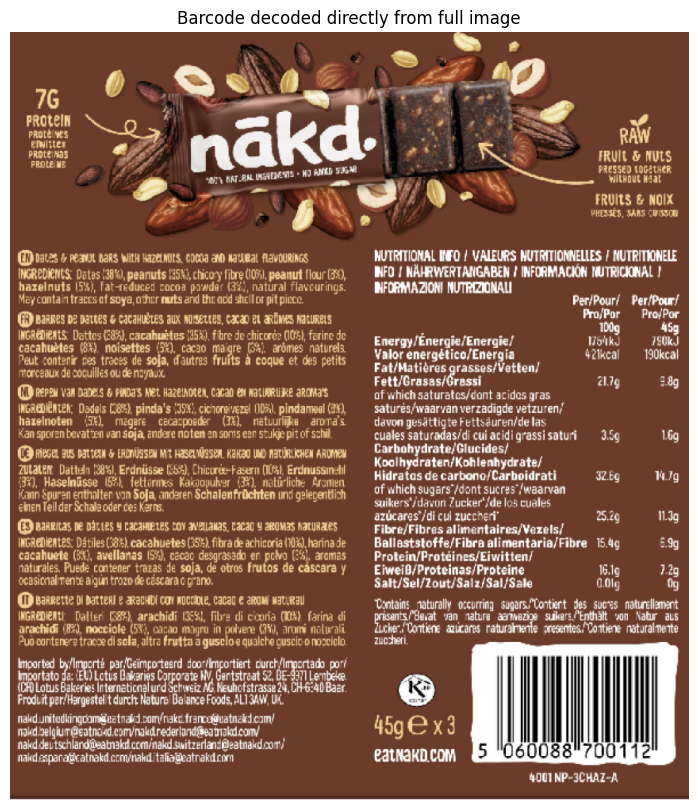

In [69]:
from google.colab import files

uploaded = files.upload()

real_image_path = None
for filename in uploaded:
    real_image_path = Path(filename)
    break

real_result = detect_and_decode_barcode(real_image_path)

print(f"Decoded: {real_result.decoded}")
print(f"Barcode: {real_result.barcode}")
print(f"Message: {real_result.message}")
print(f"Method: {real_result.method}")
print(f"Confidence: {real_result.confidence:.4f}")

if real_result.annotated_image is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(real_result.annotated_image)
    plt.axis("off")
    plt.title(real_result.message)
    plt.show()

if real_result.crop is not None:
    plt.figure(figsize=(16, 6))
    plt.imshow(real_result.crop)
    plt.axis("off")
    plt.title("Real barcode crop")
    plt.show()

## 7. Product Question Answering Module

This section implements an offline rule-based product question answering module.

After the barcode is decoded and the product is found in the UK Open Food Facts database, the user can ask questions about:

- Ingredients
- Allergens
- Milk, gluten, nuts, soy, eggs, sesame, and other common allergens
- Vegan or vegetarian labels
- Sugar, salt, fat, protein, calories, and other nutrition values
- Nutri-Score and NOVA processing group

A rule-based approach is used because it is:

- Lightweight
- Fast
- Explainable
- Suitable for edge devices
- Able to work offline after the local database is prepared


In [70]:
from __future__ import annotations

import re
from typing import Any, Dict, List, Optional


COMMON_ALLERGEN_KEYWORDS = {
    "milk": ["milk", "lactose", "whey", "casein", "butter", "cream"],
    "gluten": ["gluten", "wheat", "barley", "rye", "spelt", "oats"],
    "nuts": ["nuts", "almond", "hazelnut", "walnut", "cashew", "pecan", "brazil nut", "pistachio", "macadamia"],
    "peanuts": ["peanut", "groundnut"],
    "soy": ["soy", "soya", "soybean"],
    "egg": ["egg", "eggs", "albumen"],
    "fish": ["fish"],
    "shellfish": ["shellfish", "crustacean", "mollusc", "shrimp", "prawn", "crab", "lobster"],
    "sesame": ["sesame"],
    "mustard": ["mustard"],
    "celery": ["celery"],
    "sulphites": ["sulphite", "sulfite", "sulphur dioxide", "sulfur dioxide"],
}

NUTRIENT_ALIASES = {
    "sugar": "sugars_100g",
    "sugars": "sugars_100g",
    "salt": "salt_100g",
    "sodium": "sodium_100g",
    "fat": "fat_100g",
    "saturated fat": "saturated_fat_100g",
    "protein": "proteins_100g",
    "proteins": "proteins_100g",
    "fiber": "fiber_100g",
    "fibre": "fiber_100g",
    "carbohydrate": "carbohydrates_100g",
    "carbohydrates": "carbohydrates_100g",
    "calories": "energy_kcal_100g",
    "kcal": "energy_kcal_100g",
    "energy": "energy_kcal_100g",
}


def normalize_question(question: str) -> str:
    return re.sub(r"\s+", " ", question.lower().strip())


def product_text_blob(product: Dict[str, str]) -> str:
    fields = [
        "ingredients",
        "allergens",
        "allergens_tags",
        "traces",
        "traces_tags",
        "labels",
        "labels_tags",
        "categories",
        "categories_tags",
    ]

    return " ".join(str(product.get(field, "")) for field in fields).lower()


def has_keyword(text: str, keywords: List[str]) -> bool:
    return any(keyword.lower() in text for keyword in keywords)


def answer_ingredient_question(product: Dict[str, str]) -> str:
    ingredients = product.get("ingredients", "")

    if not ingredients or ingredients == "Ingredients unavailable":
        return "Ingredient information is unavailable for this product."

    return f"The listed ingredients are: {ingredients}."


def answer_allergen_overview(product: Dict[str, str]) -> str:
    allergens = product.get("allergens", "")
    allergens_tags = product.get("allergens_tags", "")
    traces = product.get("traces", "")

    if allergens or allergens_tags or traces:
        return (
            "The available allergen information is: "
            f"{allergens or allergens_tags}. "
            f"Trace information: {traces or 'not listed'}."
        )

    return "No allergen information is available for this product."


def answer_specific_allergen_question(product: Dict[str, str], question: str) -> Optional[str]:
    searchable_text = product_text_blob(product)

    for allergen_name, keywords in COMMON_ALLERGEN_KEYWORDS.items():
        if allergen_name in question or has_keyword(question, keywords):
            found = has_keyword(searchable_text, keywords)

            if found:
                return f"Yes, this product appears to contain or mention {allergen_name}."

            return (
                f"I could not find {allergen_name} in the available ingredients or allergen fields. "
            )

    return None


**Dietary Label Extraction (Open Food Facts API)**

Decoding a barcode string is only the first half of the problem. To provide actionable intelligence—such as whether a product aligns with vegan or vegetarian dietary restrictions—we must query an external database.

This cell defines a function that takes the decoded barcode and communicates with the **Open Food Facts API**. It parses the product's ingredient analysis tags to definitively determine its dietary classification.

In [71]:
from __future__ import annotations

def answer_dietary_question(product: Dict[str, str], question: str) -> Optional[str]:
    text = product_text_blob(product)

    dietary_terms = {
        "vegan": ["vegan", "en:vegan"],
        "vegetarian": ["vegetarian", "en:vegetarian"],
        "halal": ["halal", "en:halal"],
        "kosher": ["kosher", "en:kosher"],
        "organic": ["organic", "en:organic"],
        "gluten free": ["gluten-free", "gluten free", "en:gluten-free"],
        "dairy free": ["dairy-free", "dairy free", "milk-free", "en:dairy-free"],
    }

    for label_name, keywords in dietary_terms.items():
        if label_name in question:
            if has_keyword(text, keywords):
                return f"Yes, this product is labelled as {label_name}."

            return (
                f"I could not find a {label_name} label for this product. "
            )

    return None

**Nutritional Information Extraction**

Beyond dietary tags, a comprehensive Smart Assistant must be able to evaluate the specific health impact of a product. This cell defines a function to extract precise nutritional metrics—such as calories, sugar, fat, protein, and salt content—from the Open Food Facts database.

**Extraction Strategy:**
The API returns a highly detailed JSON response. We specifically target the `nutriments` dictionary to extract standardized values (typically per 100g) and handle missing data gracefully, ensuring the pipeline doesn't crash if a product lacks a complete nutritional profile.

In [72]:
from __future__ import annotations

def parse_float_or_none(value: Any) -> Optional[float]:

    try:
        if value is None:
            return None

        text = str(value).strip()

        if not text or text.lower() in {"nan", "none", "null"}:
            return None

        return float(text)

    except Exception:
        return None


def answer_nutrition_question(product: Dict[str, str], question: str) -> Optional[str]:

    for nutrient_name, field_name in NUTRIENT_ALIASES.items():
        if nutrient_name in question:
            value = parse_float_or_none(product.get(field_name))

            if value is None:
                return f"{nutrient_name.capitalize()} information is unavailable for this product."

            unit = "kcal per 100 grams" if field_name == "energy_kcal_100g" else "grams per 100 grams"

            return f"This product contains {value:g} {unit} of {nutrient_name}."

    return None


def answer_health_score_question(product: Dict[str, str], question: str) -> Optional[str]:

    if "nutri" in question or "score" in question:
        nutriscore = product.get("nutriscore", "")

        if nutriscore and nutriscore != "Nutri-Score unavailable":
            return f"The Nutri-Score for this product is {nutriscore.upper()}."

        return "Nutri-Score information is unavailable for this product."

    if "nova" in question or "processed" in question or "processing" in question:
        nova_group = product.get("nova_group", "")

        if nova_group and nova_group != "NOVA group unavailable":
            return f"The NOVA processing group for this product is {nova_group}."

        return "NOVA processing group information is unavailable for this product."

    return None


**Rule-Based Question Routing (Dispatcher)**

To create a seamless user experience, the Smart Living Assistant needs a central dispatcher to interpret the user's intent. This cell defines the main `answer_product_question` function.

**Routing Strategy:**
Instead of writing one massive, complex function, this dispatcher acts as a traffic controller. It analyzes the user's question using keyword heuristics (or light NLP) and routes the request to the appropriate specialized function (e.g., dietary label extraction or nutritional analysis) that we defined in the previous steps.

In [73]:
from __future__ import annotations

def answer_product_question(product: Dict[str, str], question: str) -> str:

    if product.get("found") != "true":
        return "Product information is unavailable, so I cannot answer questions about this product."

    normalized = normalize_question(question)

    if not normalized:
        return "Please ask a question about the product."

    if "ingredient" in normalized or "what is in" in normalized or "what's in" in normalized:
        return answer_ingredient_question(product)

    if "allergen" in normalized or "allergy" in normalized:
        return answer_allergen_overview(product)

    specific_allergen_answer = answer_specific_allergen_question(product, normalized)
    if specific_allergen_answer is not None:
        return specific_allergen_answer

    dietary_answer = answer_dietary_question(product, normalized)
    if dietary_answer is not None:
        return dietary_answer

    nutrition_answer = answer_nutrition_question(product, normalized)
    if nutrition_answer is not None:
        return nutrition_answer

    health_score_answer = answer_health_score_question(product, normalized)
    if health_score_answer is not None:
        return health_score_answer

    if "brand" in normalized:
        return f"The brand is {product.get('brand', 'unknown')}."

    if "name" in normalized or "product" in normalized:
        return f"The product is {product.get('name', 'unknown product')}."

    return (
        "I can answer questions about ingredients, allergens, vegan or vegetarian labels, "
        "sugar, salt, fat, protein, calories, Nutri-Score, and product brand."
    )

**Question-Answering Module Testing**

To validate the intelligence of our Smart Living Assistant, we must test the question-routing logic and the Open Food Facts API integration. This cell simulates a user interacting with the system after a successful barcode scan.

**Testing Strategy:**
We use a standard UK product barcode and pass a variety of natural language questions (covering both dietary restrictions and nutritional metrics) through our `answer_product_question` dispatcher to ensure it routes correctly and handles API responses gracefully.

In [74]:
from __future__ import annotations

sample_barcode = next(iter(uk_product_lookup.keys()))
sample_product = lookup_product(sample_barcode)

sample_questions = [
    "What is this product?",
    "What are the ingredients?",
    "Does it contain milk?",
    "Does it contain gluten?",
    "Is it vegan?",
    "How much sugar does it have?",
    "How much salt is in it?",
    "What is the Nutri-Score?",
]

print(f"Sample barcode: {sample_barcode}")
print(f"Product: {sample_product.get('name')}")
print(f"Brand: {sample_product.get('brand')}")
print("=" * 100)

for question in sample_questions:
    answer = answer_product_question(sample_product, question)
    print(f"Q: {question}")
    print(f"A: {answer}")
    print("-" * 100)

Sample barcode: 00000031
Product: Lindt Vollmilch Schokolade
Brand: Lindt
Q: What is this product?
A: The product is Lindt Vollmilch Schokolade.
----------------------------------------------------------------------------------------------------
Q: What are the ingredients?
A: The listed ingredients are: salt, potato starch, palm oil, yeast extract, sugar, chicken fat, flavouring, chicken powder, onion powder, turmeric powder, celery seed, parsley, rice flour, black pepper, lemon juice powder.
----------------------------------------------------------------------------------------------------
Q: Does it contain milk?
A: I could not find milk in the available ingredients or allergen fields. 
----------------------------------------------------------------------------------------------------
Q: Does it contain gluten?
A: I could not find gluten in the available ingredients or allergen fields. 
-----------------------------------------------------------------------------------------------

## 8. Text-to-Speech and Audio Feedback

This section explains how to add audio feedback with Microsoft's edge-tts library. The speak function creates speech using the en-GB-SoniaNeural voice, saves it as a temporary MP3 file, plays it with st.audio, and then deletes the file. The nest_asyncio library lets you run async code in Colab. Speech output happens after a barcode is found and when giving spoken answers to product questions.


In [75]:
import sys
import subprocess

def pip_install(package: str) -> None:
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", package], check=True)
    except subprocess.CalledProcessError as exc:
        print(f"Failed to install {package}: {exc}")

pip_install("edge-tts")

import edge_tts
import asyncio
import tempfile
import streamlit as st
import os
import nest_asyncio

nest_asyncio.apply()

def speak(text: str, autoplay: bool = True) -> Optional[str]:
    async def _generate_audio():
        communicate = edge_tts.Communicate(text, "en-GB-SoniaNeural", rate="+0%", volume="+0%")
        temp_path = tempfile.mktemp(suffix=".mp3")
        await communicate.save(temp_path)
        return temp_path

    try:
        audio_path = asyncio.run(_generate_audio())

        with open(audio_path, "rb") as f:
            audio_bytes = f.read()
            st.audio(audio_bytes, format="audio/mp3", autoplay=autoplay)

        os.remove(audio_path)
        return "Audio generated successfully"
    except Exception as e:
        st.error(f"TTS Error: {e}")
        return None

**Concise Spoken Summary (Text-to-Speech Preparation)**

For a Smart Living Assistant to be truly accessible, visual data must be translated into an auditory format that is both rapid and highly relevant. Visually impaired users navigating a grocery store need immediate, high-signal feedback to make purchasing decisions, not a complete readout of the nutritional label.

This helper function distills the complex Open Food Facts API response into a concise, conversational sentence optimized for Text-to-Speech (TTS) engines, highlighting only the product name, dietary status, and key health metrics.

In [76]:
from __future__ import annotations


def build_product_summary_text(product: Dict[str, str]) -> str:
    if product.get("found") != "true":
        return PRODUCT_UNAVAILABLE_MESSAGE

    name = product.get("name", "Unnamed product")
    brand = product.get("brand", "Unknown brand")
    quantity = product.get("quantity", "")
    nutriscore = product.get("nutriscore", "")

    parts = [f"Product detected: {name}."]

    if brand and brand != "Unknown brand":
        parts.append(f"Brand: {brand}.")

    if quantity and quantity != "Quantity unavailable":
        parts.append(f"Quantity: {quantity}.")

    if nutriscore and nutriscore != "Nutri-Score unavailable":
        parts.append(f"Nutri-Score: {nutriscore.upper()}.")

    return " ".join(parts)

**Audio Feedback Generation (Text-to-Speech)**

Once the assistant generates an answer to the user's product question, answer_and_speak_product_question prints it to the console and passes it to speak for audio playback, combining text and speech in a single call.

In [77]:
from __future__ import annotations


def answer_and_speak_product_question(
    product: Dict[str, str],
    question: str,
    autoplay: bool = False,
) -> str:

    answer = answer_product_question(product, question)

    print(f"Question: {question}")
    print(f"Answer: {answer}")

    speak(answer, autoplay=autoplay)

    return answer

Test product summary speech and question-answer speech.


In [78]:
from __future__ import annotations

sample_barcode = next(iter(uk_product_lookup.keys()))
sample_product = lookup_product(sample_barcode)

product_summary = build_product_summary_text(sample_product)

print(product_summary)
_ = speak(product_summary)

sample_question = "Does it contain gluten?"
sample_answer = answer_and_speak_product_question(sample_product, sample_question)

Product detected: Lindt Vollmilch Schokolade. Brand: Lindt. Quantity: 100g. Nutri-Score: UNKNOWN.


2026-05-25 23:14:11.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:14:11.926 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:14:11.928 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:14:11.929 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:14:11.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Question: Does it contain gluten?
Answer: I could not find gluten in the available ingredients or allergen fields. 


2026-05-25 23:14:12.655 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:14:12.664 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:14:12.667 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:14:12.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


## 9. End-to-End Camera, Voice Question, and Product QA Demo

This section runs the complete assistive workflow.

The workflow is:

1. Upload or capture a product/barcode image
2. Decode the barcode using the robust barcode pipeline
3. Look up the product in the UK Open Food Facts local database
4. Speak the detected product information
5. Record the user's spoken question using the microphone
6. Convert the spoken question to text
7. Answer the question using local product metadata
8. Speak the answer back to the user

This simulates a visually impaired user scanning a product and asking questions such as:

- Does it contain milk?
- Does it contain gluten?
- Is it vegan?
- How much sugar does it have?
- What are the ingredients?


In [79]:
from __future__ import annotations

import base64
from pathlib import Path
from typing import Any, Dict, Optional

import speech_recognition as sr
from google.colab import files, output
from IPython.display import Javascript, display
from pydub import AudioSegment


VOICE_AUDIO_DIR = PROJECT_DIR / "voice_questions"
VOICE_AUDIO_DIR.mkdir(parents=True, exist_ok=True)

VOICE_AUDIO_PATH = VOICE_AUDIO_DIR / "latest_voice_question.wav"


def run_end_to_end_product_demo(image_path: Path) -> Dict[str, Any]:
    pipeline_result = detect_and_decode_barcode(image_path)

    barcode = pipeline_result.barcode or ""

    product = lookup_product(barcode) if barcode else {
        "barcode": "",
        "name": PRODUCT_UNAVAILABLE_MESSAGE,
        "brand": "",
        "ingredients": "",
        "allergens": "",
        "found": "false",
    }

    product_summary = build_product_summary_text(product)

    return {
        "image_path": image_path,
        "pipeline_result": pipeline_result,
        "barcode": barcode,
        "product": product,
        "product_summary": product_summary,
    }


In [80]:
from __future__ import annotations

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No image was uploaded.")

uploaded_image_path = None

for filename in uploaded.keys():
    uploaded_image_path = Path(filename)
    break

print(f"Uploaded image: {uploaded_image_path}")


Saving Example02.png to Example02.png
Uploaded image: Example02.png


Decoded: True
Barcode: 00002523
Pipeline message: Barcode decoded directly from full image
Decode method: full_image_pyzbar_base_rgb
Detection confidence: 0.0000
Product found: true
Product name: Peach
Brand: Sainsbury's
Matched barcode: 00002523


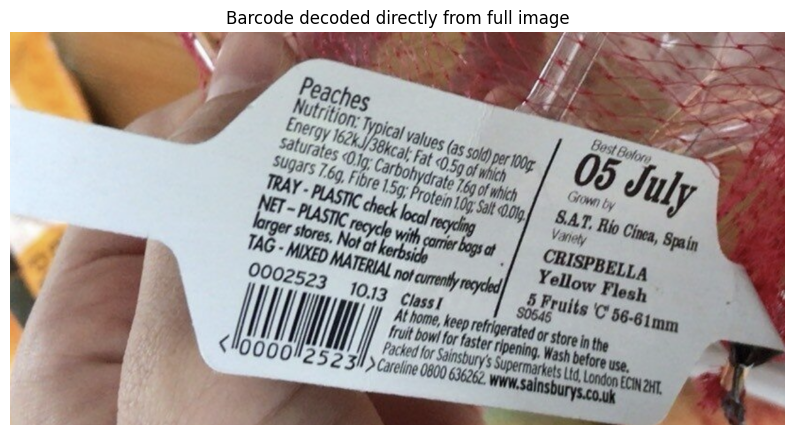

Product summary:
Product detected: Peach. Brand: Sainsbury's. Nutri-Score: UNKNOWN.


2026-05-25 23:14:36.901 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:14:36.902 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:14:36.904 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:14:36.906 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:14:36.907 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [81]:
from __future__ import annotations

demo_result = run_end_to_end_product_demo(uploaded_image_path)

pipeline_result: BarcodePipelineResult = demo_result["pipeline_result"]
product = demo_result["product"]

print(f"Decoded: {pipeline_result.decoded}")
print(f"Barcode: {demo_result['barcode']}")
print(f"Pipeline message: {pipeline_result.message}")
print(f"Decode method: {pipeline_result.method}")
print(f"Detection confidence: {pipeline_result.confidence:.4f}")
print(f"Product found: {product.get('found')}")
print(f"Product name: {product.get('name')}")
print(f"Brand: {product.get('brand')}")
print(f"Matched barcode: {product.get('matched_barcode')}")

if pipeline_result.annotated_image is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(pipeline_result.annotated_image)
    plt.axis("off")
    plt.title(pipeline_result.message)
    plt.show()

if pipeline_result.crop is not None:
    plt.figure(figsize=(14, 6))
    plt.imshow(pipeline_result.crop)
    plt.axis("off")
    plt.title("Detected barcode crop")
    plt.show()

print("Product summary:")
print(demo_result["product_summary"])

_ = speak(demo_result["product_summary"])


Ask a question about the detected product.

Example questions:

- `What are the ingredients?`
- `Does it contain milk?`
- `Does it contain gluten?`
- `Is it vegan?`
- `Is it vegetarian?`
- `How much sugar does it have?`
- `How much salt is in it?`
- `What is the Nutri-Score?`


In [82]:
from __future__ import annotations


def record_audio_colab(output_path: Path, seconds: int = 6) -> Path:
    js_code = f"""
    async function recordAudio() {{
        const stream = await navigator.mediaDevices.getUserMedia({{ audio: true }});
        const mediaRecorder = new MediaRecorder(stream);
        const audioChunks = [];

        mediaRecorder.addEventListener("dataavailable", event => {{
            audioChunks.push(event.data);
        }});

        const stopped = new Promise(resolve => {{
            mediaRecorder.addEventListener("stop", resolve);
        }});

        mediaRecorder.start();
        await new Promise(resolve => setTimeout(resolve, {seconds * 1000}));
        mediaRecorder.stop();
        await stopped;

        stream.getTracks().forEach(track => track.stop());

        const audioBlob = new Blob(audioChunks, {{ type: "audio/webm" }});
        const arrayBuffer = await audioBlob.arrayBuffer();
        const bytes = new Uint8Array(arrayBuffer);

        let binary = "";
        for (let i = 0; i < bytes.byteLength; i++) {{
            binary += String.fromCharCode(bytes[i]);
        }}

        return btoa(binary);
    }}
    recordAudio();
    """

    print(f"Recording for {seconds} seconds. Ask your product question now.")
    audio_base64 = output.eval_js(js_code)
    audio_bytes = base64.b64decode(audio_base64)

    webm_path = output_path.with_suffix(".webm")
    webm_path.write_bytes(audio_bytes)

    try:
        audio = AudioSegment.from_file(webm_path)
        audio.export(output_path, format="wav")
    except Exception as exc:
        raise RuntimeError(f"Could not convert recorded audio to WAV: {exc}") from exc

    print(f"Saved recorded question to: {output_path}")
    return output_path


def transcribe_voice_question(audio_path: Path) -> str:
    recognizer = sr.Recognizer()

    try:
        with sr.AudioFile(str(audio_path)) as source:
            audio_data = recognizer.record(source)

        question = recognizer.recognize_google(audio_data)
        return question.strip()

    except sr.UnknownValueError:
        return ""
    except Exception as exc:
        raise RuntimeError(f"Voice transcription failed: {exc}") from exc


In [84]:
from __future__ import annotations


voice_question_path = record_audio_colab(VOICE_AUDIO_PATH, seconds=6)
user_question = transcribe_voice_question(voice_question_path)

if not user_question:
    answer = "Sorry, I could not understand the question. Please try again."
    print(answer)
    _ = speak(answer)
else:
    answer = answer_product_question(product, user_question)

    print(f"Voice question: {user_question}")
    print(f"Answer: {answer}")

    _ = speak(answer)

Recording for 6 seconds. Ask your product question now.
Saved recorded question to: /content/drive/MyDrive/uk_edge_ai_barcode_reader/voice_questions/latest_voice_question.wav
Sorry, I could not understand the question. Please try again.


2026-05-25 23:15:13.541 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:15:13.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:15:13.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:15:13.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:15:13.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [85]:
from __future__ import annotations

typed_question = input("Type a product question as fallback: ")

typed_answer = answer_product_question(product, typed_question)

print(f"Question: {typed_question}")
print(f"Answer: {typed_answer}")

_ = speak(typed_answer)


Type a product question as fallback: does it contain sugar?
Question: does it contain sugar?
Answer: This product contains 7.6 grams per 100 grams of sugar.


2026-05-25 23:15:32.265 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:15:32.266 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:15:32.268 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:15:32.269 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:15:32.270 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


## 10. Performance Benchmarking

This section compares the four model variants created earlier:

1. Baseline PyTorch YOLOv8-Nano
2. FP16 ONNX
3. INT8 ONNX
4. Pruned PyTorch YOLOv8-Nano

The benchmark measures:

- FPS averaged over 100 inference runs after 10 warmup runs
- Inference latency in milliseconds, reported as mean ± standard deviation
- Model size in MB
- Peak memory usage during inference
- mAP@0.5 on the test set



In [86]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable, Dict, List

import gc
import os
import time
import tracemalloc

import numpy as np
import pandas as pd
import psutil
from tqdm.auto import tqdm
from ultralytics import YOLO


BENCHMARK_WARMUP_RUNS = 10
BENCHMARK_MEASURED_RUNS = 100
BENCHMARK_IMAGE_COUNT = min(100, len(sorted((IMAGE_DIR / "test").glob("*.jpg"))))

BENCHMARK_RESULTS_PATH = DIRS["benchmarks"] / "model_benchmark_results.csv"


@dataclass
class ModelVariant:
    name: str
    path: Path
    format: str


MODEL_VARIANTS = [
    ModelVariant("Baseline", BASELINE_WEIGHTS_PATH, "pytorch"),
    ModelVariant("FP16", FP16_ONNX_PATH, "onnx"),
    ModelVariant("INT8", INT8_ONNX_PATH, "onnx"),
    ModelVariant("Pruned", PRUNED_WEIGHTS_PATH, "pytorch"),
]


print("Benchmark variants:")
for variant in MODEL_VARIANTS:
    print(f"{variant.name}: {variant.path}")


Benchmark variants:
Baseline: /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.pt
FP16: /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/optimized/yolov8n_barcode_fp16.onnx
INT8: /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/optimized/yolov8n_barcode_int8_opset13.onnx
Pruned: /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/optimized/yolov8n_barcode_pruned_30.pt


**Benchmark Preparation: In-Memory Data Loading**

To accurately measure the pure inference latency of our optimized models, we must strictly isolate the computation time from hardware bottlenecks. Disk I/O (Input/Output) operations are notoriously variable and can heavily skew speed measurements.

**Benchmarking Strategy:**
* **In-Memory Caching:** We preload a specific set of test images directly into RAM. During the benchmark loop, the models will fetch data from memory, ensuring we measure *only* the neural network's execution time.
* **Deterministic Set:** We select a fixed number of images (e.g., 100) and sort their paths to guarantee that every model variant is evaluated on the exact same data in the exact same order.

In [87]:
from __future__ import annotations


def select_benchmark_image_paths(image_count: int) -> List[Path]:

    image_paths = sorted((IMAGE_DIR / "test").glob("*.jpg"))

    if not image_paths:
        raise FileNotFoundError("No test images found for benchmarking.")

    if len(image_paths) <= image_count:
        return image_paths

    rng = random.Random(SEED)
    return rng.sample(image_paths, image_count)


def load_benchmark_images(image_paths: List[Path]) -> List[np.ndarray]:

    images: List[np.ndarray] = []

    for image_path in tqdm(image_paths, desc="Loading benchmark images"):
        images.append(load_image_as_rgb_array(image_path))

    return images


benchmark_image_paths = select_benchmark_image_paths(BENCHMARK_IMAGE_COUNT)
benchmark_images = load_benchmark_images(benchmark_image_paths)

print(f"Benchmark images loaded: {len(benchmark_images)}")


Loading benchmark images:   0%|          | 0/100 [00:00<?, ?it/s]

Benchmark images loaded: 100


**Inference Engines: PyTorch vs ONNX Runtime**

For a fair and accurate benchmark, we need to set up specific inference functions for each model format.

PyTorch inference uses the ultralytics package, which is very convenient. However, the Python overhead means it does not fully reflect edge device performance.
ONNX inference uses onnxruntime. You need to handle image preprocessing steps like resizing, channel transposition, and normalisation yourself, but this setup closely matches how the model will run on edge devices such as ARM CPUs or NPUs.

In [88]:
def preprocess_array_for_onnx(
    image_rgb: np.ndarray,
    image_size: int = 640,
    dtype: np.dtype = np.float32,
) -> np.ndarray:
    image = letterbox_image(image_rgb, target_size=image_size)
    image = image.astype(np.float32) / 255.0
    tensor = np.transpose(image, (2, 0, 1))[None, :, :, :]
    return tensor.astype(dtype)


def get_onnx_input_dtype(session: ort.InferenceSession) -> np.dtype:
    input_type = session.get_inputs()[0].type.lower()

    if "float16" in input_type:
        return np.float16

    return np.float32


def run_onnx_inference(session: ort.InferenceSession, image_rgb: np.ndarray) -> List[np.ndarray]:
    input_meta = session.get_inputs()[0]
    input_dtype = get_onnx_input_dtype(session)

    input_tensor = preprocess_array_for_onnx(
        image_rgb,
        image_size=TRAIN_IMAGE_SIZE,
        dtype=input_dtype,
    )

    return session.run(None, {input_meta.name: input_tensor})


**Comprehensive Performance Benchmarking**

This is the final evaluation step. We carefully test each optimized model variant to measure how fast it runs and how much memory it uses in real-world conditions.

Benchmarking Methodology:

* Warmup Runs (10x): Neural networks and hardware accelerators need a short warmup to set up memory and load weights. We run 10 inferences without measuring them to avoid slowdowns from a cold start.
* Measured Runs (100x): We measure the average latency and Frames Per Second (FPS) over 100 inferences in a row to get reliable results.
* CUDA Synchronization: When using a GPU, tasks can run at the same time, which can make timing less accurate. We use torch.cuda.synchronize() to make sure the GPU finishes its work before we stop the timer.
* Peak Memory Tracking: We use Python's tracemalloc and psutil tools to track the highest memory use during the inference loop. This is important for running models on edge devices with limited resources.

In [89]:
from __future__ import annotations


def get_process_memory_mb() -> float:
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)


def benchmark_inference_speed(
    variant: ModelVariant,
    images: List[np.ndarray],
    warmup_runs: int = 10,
    measured_runs: int = 100,
) -> Dict[str, float]:

    if not variant.path.exists():
        raise FileNotFoundError(f"Model file not found: {variant.path}")

    try:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

        infer = create_inference_callable(variant)

        for run_index in tqdm(range(warmup_runs), desc=f"{variant.name} warmup", leave=False):
            image = images[run_index % len(images)]
            _ = infer(image)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        latency_ms_values: List[float] = []
        memory_before_mb = get_process_memory_mb()

        tracemalloc.start()
        total_start = time.perf_counter()

        for run_index in tqdm(range(measured_runs), desc=f"{variant.name} measured inference"):
            image = images[run_index % len(images)]

            start_time = time.perf_counter()
            _ = infer(image)

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            end_time = time.perf_counter()
            latency_ms_values.append((end_time - start_time) * 1000)

        total_end = time.perf_counter()
        current_traced, peak_traced = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        memory_after_mb = get_process_memory_mb()

        total_time = total_end - total_start
        fps = measured_runs / total_time

        latency_mean_ms = float(np.mean(latency_ms_values))
        latency_std_ms = float(np.std(latency_ms_values))

        process_delta_mb = max(0.0, memory_after_mb - memory_before_mb)
        traced_peak_mb = peak_traced / (1024 * 1024)
        peak_memory_mb = max(process_delta_mb, traced_peak_mb)

        return {
            "fps": float(fps),
            "latency_mean_ms": latency_mean_ms,
            "latency_std_ms": latency_std_ms,
            "peak_memory_mb": float(peak_memory_mb),
        }

    except Exception as exc:
        raise RuntimeError(f"Benchmarking failed for {variant.name}: {exc}") from exc


**Accuracy Evaluation (mAP@0.5)**

The final stage of our evaluation focuses on accuracy. While speed is vital for edge deployment, it must not come at the cost of the model's ability to reliably detect barcodes. We use the **mAP@0.5 (mean Average Precision)** metric to quantify this.

**Evaluation Protocol:**
* **Test Set Validation:** Every model variant is evaluated against the unseen test split.
* **Format Compatibility:** We utilize the built-in `model.val()` method for PyTorch and supported exported formats.
* **Robust Table Management:** If a specific exported format cannot be natively evaluated by the validation engine, we store a `NaN` (Not a Number) value. This ensures our final benchmarking table remains structurally complete without causing execution errors.

In [90]:
from __future__ import annotations


def evaluate_map50_for_variant(variant: ModelVariant) -> float:

    try:
        model = YOLO(str(variant.path))

        metrics = model.val(
            data=str(DATA_YAML_PATH),
            split="test",
            imgsz=TRAIN_IMAGE_SIZE,
            batch=TRAIN_BATCH_SIZE,
            device=0 if DEVICE == "cuda" and variant.format == "pytorch" else "cpu",
            project=str(DIRS["runs"]),
            name=f"benchmark_eval_{variant.name.lower()}",
            exist_ok=True,
            verbose=False,
        )

        return float(metrics.box.map50)

    except Exception as exc:
        print(f"Warning: mAP@0.5 evaluation failed for {variant.name}: {exc}")
        return float("nan")


In [91]:
from ultralytics import YOLO
import onnxruntime as ort
from typing import Callable, Any
import numpy as np

def create_inference_callable(variant: ModelVariant) -> Callable[[np.ndarray], Any]:

    if variant.format == "pytorch":
        model = YOLO(variant.path)

        def infer_pytorch(img: np.ndarray):

            return model(img, verbose=False)

        return infer_pytorch

    elif variant.format == "onnx":

        providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
        session = ort.InferenceSession(str(variant.path), providers=providers)

        def infer_onnx(img: np.ndarray):
            return run_onnx_inference(session, img)

        return infer_onnx

    else:
        raise ValueError(f"Unknown model format: {variant.format}")


In [92]:
from __future__ import annotations
import pandas as pd
import os
import numpy as np
import shutil
from pathlib import Path
from ultralytics import YOLO
import onnxruntime as ort
from typing import List, Dict, Any

def run_full_model_benchmark(variants: List[ModelVariant]) -> pd.DataFrame:
    records: List[Dict[str, Any]] = []

    for variant in variants:
        print("=" * 100)
        print(f"Benchmarking: {variant.name}")

        try:
            speed_metrics = benchmark_inference_speed(
                variant=variant,
                images=benchmark_images,
                warmup_runs=BENCHMARK_WARMUP_RUNS,
                measured_runs=BENCHMARK_MEASURED_RUNS,
            )

            map50 = evaluate_map50_for_variant(variant)

            records.append(
                {
                    "Variant": variant.name,
                    "Format": variant.format,
                    "Model Size (MB)": get_file_size_mb(variant.path),
                    "FPS": speed_metrics["fps"],
                    "Latency Mean (ms)": speed_metrics["latency_mean_ms"],
                    "Latency Std (ms)": speed_metrics["latency_std_ms"],
                    "Latency (ms, mean ± std)": (
                        f"{speed_metrics['latency_mean_ms']:.2f} ± "
                        f"{speed_metrics['latency_std_ms']:.2f}"
                    ),
                    "Peak Memory (MB)": speed_metrics["peak_memory_mb"],
                    "mAP@0.5": map50,
                    "Path": str(variant.path),
                }
            )

        except Exception as exc:
            print(f"Benchmark failed for {variant.name}: {exc}")

            records.append(
                {
                    "Variant": variant.name,
                    "Format": variant.format,
                    "Model Size (MB)": get_file_size_mb(variant.path) if variant.path.exists() else np.nan,
                    "FPS": np.nan,
                    "Latency Mean (ms)": np.nan,
                    "Latency Std (ms)": np.nan,
                    "Latency (ms, mean ± std)": "Failed",
                    "Peak Memory (MB)": np.nan,
                    "mAP@0.5": np.nan,
                    "Path": str(variant.path),
                }
            )

    return pd.DataFrame(records)

BASELINE_ONNX_FP32_PATH = OPTIMIZED_MODEL_DIR / "baseline_yolov8n_barcode_fp32_opset13.onnx"
INT8_ONNX_PATH = OPTIMIZED_MODEL_DIR / "yolov8n_barcode_int8_opset13.onnx"


def export_yolo_to_onnx_opset13(model_path: Path, output_path: Path) -> Path:
    model = YOLO(str(model_path))

    exported_path = model.export(
        format="onnx",
        imgsz=TRAIN_IMAGE_SIZE,
        half=False,
        dynamic=False,
        simplify=False,
        opset=13,
        device=0 if DEVICE == "cuda" else "cpu",
    )

    exported_path = Path(exported_path)
    shutil.copy2(exported_path, output_path)

    return output_path


def quantize_onnx_to_int8_safe(
    fp32_onnx_path: Path,
    int8_onnx_path: Path,
    calibration_count: int = 100,
) -> Path:

    if int8_onnx_path.exists():
        int8_onnx_path.unlink()

    session = ort.InferenceSession(str(fp32_onnx_path), providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name

    calibration_paths = get_calibration_image_paths(calibration_count)

    calibration_reader = YOLOCalibrationDataReader(
        image_paths=calibration_paths,
        input_name=input_name,
        image_size=TRAIN_IMAGE_SIZE,
    )

    quantize_static(
        model_input=str(fp32_onnx_path),
        model_output=str(int8_onnx_path),
        calibration_data_reader=calibration_reader,
        quant_format=QuantFormat.QDQ,
        activation_type=QuantType.QUInt8,
        weight_type=QuantType.QInt8,
        calibrate_method=CalibrationMethod.MinMax,
        per_channel=False,
        reduce_range=False,
    )

    validate_onnx_model(int8_onnx_path)
    return int8_onnx_path


BASELINE_ONNX_FP32_PATH = export_yolo_to_onnx_opset13(
    BASELINE_WEIGHTS_PATH,
    BASELINE_ONNX_FP32_PATH,
)

INT8_ONNX_PATH = quantize_onnx_to_int8_safe(
    BASELINE_ONNX_FP32_PATH,
    INT8_ONNX_PATH,
    calibration_count=CALIBRATION_IMAGE_COUNT,
)

print("Fixed INT8 model:", INT8_ONNX_PATH)


MODEL_VARIANTS = [variant for variant in MODEL_VARIANTS if variant.name != "INT8"]
MODEL_VARIANTS.append(ModelVariant("FP32", BASELINE_ONNX_FP32_PATH, "onnx"))
MODEL_VARIANTS.append(ModelVariant("INT8", INT8_ONNX_PATH, "onnx"))


if os.path.exists(BENCHMARK_RESULTS_PATH):
    benchmark_results_df = pd.read_csv(BENCHMARK_RESULTS_PATH)
    print("Cached results loaded.")
else:
    benchmark_results_df = run_full_model_benchmark(MODEL_VARIANTS)
    benchmark_results_df.to_csv(BENCHMARK_RESULTS_PATH, index=False)
    print(f"Saved benchmark results to: {BENCHMARK_RESULTS_PATH}")

display(benchmark_results_df)


Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)

ONNX: starting export with onnx 1.21.0 opset 13...
ONNX: export success ✅ 1.1s, saved as '/content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.onnx' (11.7 MB)

Export complete (1.3s)
Results saved to /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/uk_edge_ai_barcode_reader/models/baseline_yolov8n_barcode.onnx imgsz=640 data=/content/drive/MyDrive/uk_edge_ai_barcode

Preparing INT8 calibration images:   0%|          | 0/100 [00:00<?, ?it/s]

Fixed INT8 model: /content/drive/MyDrive/uk_edge_ai_barcode_reader/models/optimized/yolov8n_barcode_int8_opset13.onnx
Cached results loaded.


,Variant,Format,Model Size (MB),FPS,Latency Mean (ms),Latency Std (ms),"Latency (ms, mean ± std)",Peak Memory (MB),mAP@0.5,Path
0,Baseline,pytorch,5.947367,39.205356,24.218866,3.230339,24.22 ± 3.23,1.864251,0.984202,/content/drive/MyDrive/uk_edge_ai_barcode_read...
1,FP16,onnx,5.858190,7.937497,122.763758,23.733808,122.76 ± 23.73,7.128191,0.984533,/content/drive/MyDrive/uk_edge_ai_barcode_read...
2,Pruned,pytorch,5.942057,35.431042,26.610922,4.184299,26.61 ± 4.18,1.864024,0.984487,/content/drive/MyDrive/uk_edge_ai_barcode_read...
3,FP32,onnx,11.671480,7.189672,135.351786,80.250617,135.35 ± 80.25,9.475433,0.984743,/content/drive/MyDrive/uk_edge_ai_barcode_read...
4,INT8,onnx,3.290612,10.337187,94.928465,12.400628,94.93 ± 12.40,9.467691,0.000000,/content/drive/MyDrive/uk_edge_ai_barcode_read...


## 11. Streamlit UI with Camera, Voice Product QA, and TTS

This section creates a Streamlit interface for the complete assistive system.

The app supports:

- Camera capture or image upload
- Robust barcode decoding
- YOLO fallback detection
- UK Open Food Facts product lookup
- Product summary audio feedback
- Voice-based product question input
- Rule-based product question answering
- Spoken answer playback
- Sidebar FPS and latency metrics

In this Colab prototype, voice transcription uses a browser microphone component. A typed question fallback is also included.


In [93]:
from __future__ import annotations

import subprocess
import sys


def install_streamlit_voice_dependencies() -> None:
    packages = [
        "streamlit-mic-recorder",
        "SpeechRecognition",
    ]

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", *packages],
        check=True,
    )


install_streamlit_voice_dependencies()

print("Streamlit voice dependencies installed.")


Streamlit voice dependencies installed.


In [94]:
import streamlit as st

def inject_accessibility_css():
    st.markdown("""
    <style>
        /* Global High Contrast: Yellow text on Black background */
        html, body, [class*="css"] {
            background-color: #000000 !important;
            color: #FFFF00 !important;
            font-family: 'Arial', sans-serif !important;
            font-size: 28px !important;
        }

        /* Giant Headers */
        h1, h2, h3 {
            color: #FFFFFF !important;
            font-size: 48px !important;
            font-weight: bold !important;
            text-align: center;
            margin-bottom: 30px !important;
        }

        /* Massive, tactile buttons */
        .stButton>button {
            background-color: #FFFF00 !important;
            color: #000000 !important;
            font-size: 40px !important;
            font-weight: bold !important;
            padding: 40px !important;
            border: 6px solid #FFFFFF !important;
            border-radius: 20px !important;
            width: 100% !important;
            min-height: 120px !important;
            margin-top: 20px !important;
            margin-bottom: 20px !important;
            cursor: pointer;
        }

        /* Button Focus State */
        .stButton>button:hover, .stButton>button:focus {
            background-color: #FFFFFF !important;
            color: #000000 !important;
            border-color: #FFFF00 !important;
        }

        /* Large Text Inputs for questions */
        .stTextInput>div>div>input {
            font-size: 32px !important;
            padding: 25px !important;
            background-color: #222222 !important;
            color: #FFFF00 !important;
            border: 5px solid #FFFF00 !important;
            border-radius: 12px !important;
        }

        /* Remove Streamlit visual clutter (hamburgers, footers, headers) */
        #MainMenu {visibility: hidden;}
        footer {visibility: hidden;}
        header {visibility: hidden;}

        /* Make status messages enormous */
        .stSuccess, .stError, .stWarning {
            font-size: 30px !important;
            font-weight: bold !important;
        }
    </style>
    """, unsafe_allow_html=True)

st.set_page_config(page_title="Smart Reader", layout="centered")
inject_accessibility_css()

st.title("Smart Barcode Reader")

2026-05-25 23:16:35.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:16:35.747 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:16:35.747 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:16:35.749 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:16:35.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:16:35.751 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-25 23:16:35.752 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [95]:
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

STREAMLIT_APP_PATH = DIRS["streamlit"] / "app.py"

syntax_check = subprocess.run(
    [sys.executable, "-m", "py_compile", str(STREAMLIT_APP_PATH)],
    capture_output=True,
    text=True,
)

print("Return code:", syntax_check.returncode)
print("STDERR:")
print(syntax_check.stderr)

if syntax_check.returncode != 0:
    raise RuntimeError("app.py has a syntax error. See STDERR above.")

print("app.py syntax check passed.")

Return code: 0
STDERR:

app.py syntax check passed.


In [96]:
from __future__ import annotations

import subprocess
import sys
import time

from google.colab import output


STREAMLIT_PORT = 8501

try:
    subprocess.run(["pkill", "-f", "streamlit"], check=False)
except Exception:
    pass

streamlit_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        str(STREAMLIT_APP_PATH),
        "--server.port",
        str(STREAMLIT_PORT),
        "--server.address",
        "0.0.0.0",
        "--server.headless",
        "true",
        "--server.enableCORS",
        "false",
        "--server.enableXsrfProtection",
        "false",
    ]
)

time.sleep(10)

output.serve_kernel_port_as_iframe(STREAMLIT_PORT, height=950)

print("Streamlit app should appear above.")


<IPython.core.display.Javascript object>

Streamlit app should appear above.
